<a href="https://colab.research.google.com/github/R23062/idk/blob/main/eii2_%E7%AC%AC03%E5%9B%9E_2026_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **報告書1の作成と提出について**

- [こちら](https://colab.research.google.com/drive/147iZ0SBQ5iMW0GGkIHpc6FtIi2zwMoKB?usp=sharing)を参照してください。

In [ ]:
# matplotlib で日本語を使用するためのパッケージのインストール
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 28.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=9ff1911d11e10a026fb1ea2be3f5e9e5cec9a889813a25d656959c237d1b1ad0
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


# 母平均の区間推定（前回のつづき）

[第2回](https://colab.research.google.com/drive/1SSEeJD9AC-JK68mvrApck_bo6hi5Ihag?usp=sharing) では、推測統計として、母平均の点推定、母分散の点推定、母平均の区間推定 (途中まで) を学びました。

第3回 では、**母平均の区間推定** のつづき、**統計的仮説検定** について学びます。前回までの内容を理解している前提の解説なので注意してください。

## **<font color="deeppink">目的3</font>（再掲）**

**母平均** $\mu$ の「$95\%$信頼区間」が、次のように標本に基づいて「**区間推定**」できることを、Python を用いたシミュレーション実験を通じて実証的に確認し、その理解を深める。

> $$ \left[ \bar{x} - t \cdot \mathrm{SE},\; \bar{x} + t \cdot \mathrm{SE} \right] = \left[ \bar{x} - t \cdot \frac{u}{\sqrt{n}},\; \bar{x} + t \cdot \frac{u}{\sqrt{n}} \right] $$
>
> ここで $t$ は、自由度 $n-1$ の「$t$ 分布」における上側確率 $2.5\%$ 点の値とする。
>  
> また、$\mathrm{SE}$ は、標本平均 $\bar{x}$ のばらつき（推定の不確かさ）を表す**標準誤差**とする。

以下、前回からの「**つづき**」の解説となります。

いま、母集団 $\Omega$ から無作為抽出した標本 $\mathrm{S}$ の**標本平均** $\bar{x}$ が、ある確率分布に従うことが分かっていると仮定します。

例えば、母集団 $\Omega$ から抽出した<font color='deeppink'>サンプルサイズ $n$ の標本 $\mathrm{S}$ の平均 $\bar{x}$ が、$N(70,6^2)$ の正規分布に従うことが分かっているものと仮定します</font>。すなわち、$\bar{x}$ が、以下に示すような $N(70,6^2)$ の確率密度関数 $f(\bar{x})$ に従うことが既知である状況を考えます。

<br>

$$
\begin{aligned}
 f_{N(70,\,6^2)}(\bar{x}) &= \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{(\bar{x} -\mu)^2}{2\sigma^2} \right) \\
&= \frac{1}{6\sqrt{2\pi}} \exp\left( -\frac{(\bar{x} - 70)^2}{2\times6^2} \right)
\end{aligned}
$$

<br>

- 確率密度関数（PDF: Probability Density Function）
  - 確率密度関数 $f(\bar{x})$ の曲線の高さは確率の相対的な集中度 (値が現れやすい度合い) を表しています。
  - 確率密度関数 $f(\bar{x})$ を $-\infty$ から  $\infty$ まで積分したときの面積は、常に $1.0$ になります。

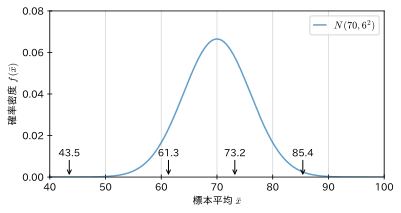

In [ ]:
#@title 図：$N (70, 6^2)$ の確率密度関数の描画 { display-mode: "form" }
%reset -f
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import japanize_matplotlib
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

mu, sigma = (70, 6)
x_min, x_max = (40,100)

x = np.linspace(x_min, x_max, 300)
pdf = st.norm.pdf(x, loc=mu, scale=sigma)

fig,ax = plt.subplots(figsize=(6,3),facecolor='white')
ax.plot(x, pdf, alpha=0.7, label=f'$N\\,({mu}, {sigma}^2)$')
ax.tick_params(axis='both', direction='inout', length=5)

for xs in [43.5, 85.4, 61.3, 73.2]:
  ax.annotate('', xytext=(xs, 0.009), xy=(xs, 0), arrowprops=dict(arrowstyle='->'))
  t = ax.text(xs,0.01,f'{xs:.1f}',ha='center')
  t.set_path_effects([pe.Stroke(linewidth=3,foreground='white'),pe.Normal()])

ax.grid(axis='x',alpha=0.5)
ax.set_xlim(x_min, x_max)
ax.set_yticks(np.linspace(0,0.08,5))
ax.set_ylim(0,0.08)
ax.set_xlabel('標本平均 $\\bar{x}$')
ax.set_ylabel('確率密度 $f\\,( \\bar{x} )$')
ax.legend(handlelength=1.2)
plt.show()

この確率密度関数 $f(\bar{x})$ のグラフから、標本平均 $\bar{x}$ が $43.5$ や $85.4$ といった値をとることは<font color='deeppink'>極めて稀</font>で、逆に $61.3$ や $73.2$ といった値になることは十分にあり得るということが分かると思います。また、$\bar{x}$ が $70$ 以下となる確率は $50\%$ ということも分かると思います。

- $-\infty$ から $70$ の範囲で $f(\bar{x})$ を 積分すると $0.5$ になることが分かると思います。

確率密度関数 $f(\bar{x})$  からは「標本平均 $\bar{x}$ が特定の区間に含まれる確率」を定量的に求めることができます。例えば「$58.24 \le \bar{x} \le 81.76$ となる確率」は、次式から $95.0\%$ と計算できます。

$$ P(58.24 \leq \bar{x} \leq 81.76) = \int_{58.24}^{81.76} f_{N(70,\,6^2)}(\bar{x})\, d\bar{x} = 0.95 $$

Python の **<font color="deeppink">SymPy（数式処理ライブラリ）</font>** を使って、次のように確認することができます。



In [ ]:
%reset -f
from sympy import Symbol, integrate, sqrt, pi, exp, N, erf
x = Symbol('x')
mu, sigma = 70, 6
pdf = (1 / (sigma * sqrt(2 * pi))) * exp(-((x - mu)**2) / (2 * sigma**2))
prob = integrate(pdf, (x, 58.24, 81.76)) # 積分計算
print(f'{N(prob):.3f}') # 数値評価

0.950


この関係を Matplotlib を使用して図示すると次のようになります。

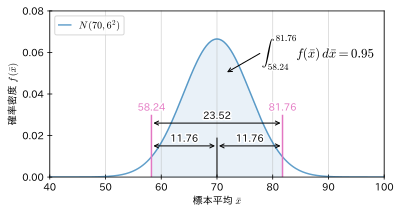

In [ ]:
#@title 図：$N(70, 6^2)$ の $95\%$ 質量範囲 { display-mode: "form" }
%reset -f
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.patheffects as pe
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

mu, sigma = (70, 6)
x_min, x_max = (40,100)

x = np.linspace(x_min, x_max, 300)
pdf = st.norm.pdf(x, loc=mu, scale=sigma)

# 95%信頼区間に対応する下限と上限を計算
lower_95 = st.norm.ppf(0.025, loc=mu, scale=sigma)  # 左側 2.5%点
upper_95 = st.norm.ppf(0.975, loc=mu, scale=sigma)  # 右側97.5%点

fig,ax = plt.subplots(figsize=(6,3),facecolor='white')

mask = (x >= lower_95) & (x <= upper_95)
x_fill = x[mask]
y_fill = pdf[mask]
ax.fill_between(x_fill, y_fill, color='tab:blue', alpha=0.1)

ax.plot(x, pdf, alpha=0.7, label=f'$N\\,({mu}, {sigma}^2)$')
ax.tick_params(axis='both', direction='inout', length=5)

base_h = 0.03
d = 0.004
ax.vlines(mu,ymin=0, ymax=base_h/2+d, color='k', lw=1)
ax.annotate('', xytext=(lower_95, base_h-d), xy=(upper_95, base_h-d),arrowprops=dict(arrowstyle='<->'))
t = ax.text(mu, base_h-d/2, f'{upper_95-lower_95:.2f}',ha='center')
t.set_path_effects([pe.Stroke(linewidth=3,foreground='white'),pe.Normal()])

for w in (lower_95, upper_95):
  ax.vlines(w,ymin=0, ymax=base_h, color='tab:pink', lw=1.5)
  t = ax.text(w, base_h+d/2, f'{w:.2f}',ha='center',color='tab:pink')
  t.set_path_effects([pe.Stroke(linewidth=3,foreground='white'),pe.Normal()])

  ax.annotate('', xytext=(w, base_h/2), xy=(mu, base_h/2),arrowprops=dict(arrowstyle='<->'))
  t = ax.text( mu-(mu-w)/2, base_h/2+d/2, f'{abs(mu-w):.2f}',ha='center')
  t.set_path_effects([pe.Stroke(linewidth=3,foreground='white'),pe.Normal()])


ax.annotate('', xytext=(78, 0.06), xy=(71.5, 0.05),arrowprops=dict(arrowstyle='->'))
t = ax.text(78, 0.060, f'$\\int_{{{lower_95:.2f}}}^{{{upper_95:.2f}}}f(\\bar{{x}})\\, d\\bar{{x}}=0.95$',va='center',fontsize=13)
t.set_path_effects([pe.Stroke(linewidth=3,foreground='white'),pe.Normal()])

ax.grid(axis='x',alpha=0.5)
ax.set_xlim(x_min, x_max)
ax.set_yticks(np.linspace(0,0.08,5))
ax.set_ylim(0,0.08)
ax.set_xlabel('標本平均 $\\bar{x}$')
ax.set_ylabel('確率密度 $f\\,( \\bar{x} )$')
ax.legend(handlelength=1.2,loc='upper left')
plt.show()

以上のことは、仮に標本抽出を $100$ 回実行すれば、そのうち 約 $95$ 回は「母平均 $\mu$ を中心とした $\pm 11.76$ の範囲内に $\bar{x}$ が収まる」ということを意味します。この関係を逆に捉えると...

- <font color='deeppink'> $\bar{x}$ を中心とした $\pm 11.76$ の区間内に、母平均 $\mu$ が $95\%$ の確率で含まれる</font>

...ともいえます。

以下の例では、$\bar{x}_{1}$、$\bar{x}_{2}$、$\bar{x}_{4}$ は、その $\pm11.76$ の区間内に母平均 $\mu$ を捕らえています。


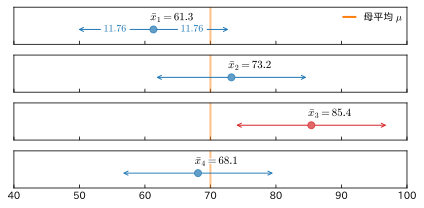

In [ ]:
#@title 図：標本平均を基準とした $95\%$ 信頼区間と母平均 $\mu$ の関係 { display-mode: "form" }
%reset -f
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

mu, sigma = (70, 6)
x_min, x_max = (40,100)

lower_95 = st.norm.ppf(0.025, loc=mu, scale=sigma)  # 左側 2.5%点
upper_95 = st.norm.ppf(0.975, loc=mu, scale=sigma)  # 右側97.5%点

fig,axes = plt.subplots(nrows=4, ncols=1, figsize=(6,3), sharex='col',facecolor='white')
axes = axes.ravel() # 平坦化

x = [61.3,73.2,85.4,68.1]
d = 0.05
w = (upper_95 - lower_95)/2

for i in range(4):
  ax = axes[i]
  ax.tick_params(axis='both', direction='in')

  c = 'tab:blue' if i != 2 else 'tab:red'

  ax.scatter(x[i],0.4,clip_on=False, s=50, alpha=0.7, color=c)
  t = ax.text(x[i]-d*10, 0.6+d, f'$\\bar{{x}}_{{{i+1}}}={x[i]:.1f}$',fontsize=11)
  t.set_path_effects([pe.Stroke(linewidth=3,foreground='white'),pe.Normal()])

  ax.annotate('', xytext=(x[i]+d*5, 0.4), xy=(x[i]+w, 0.4), arrowprops=dict(arrowstyle='->',color=c))
  ax.annotate('', xytext=(x[i]-d*5, 0.4), xy=(x[i]-w, 0.4), arrowprops=dict(arrowstyle='->',color=c))

  if i == 0:
    t = ax.text(x[i]-w/2, 0.42, f'${w:.2f}$',ha='center',va='center',color=c)
    t.set_path_effects([pe.Stroke(linewidth=8,foreground='white'),pe.Normal()])
    t = ax.text(x[i]+w/2, 0.42, f'${w:.2f}$',ha='center',va='center',color=c)
    t.set_path_effects([pe.Stroke(linewidth=8,foreground='white'),pe.Normal()])

  ax.axvline(mu,color='tab:orange',lw=2, alpha=0.5, label=f'$mu=70$')
  ax.set_xlim(x_min, x_max)
  ax.set_yticks([])
  ax.set_ylim(0,1)
  if i == len(axes):
    ax.set_xlabel('標本平均 $\\bar{x}$')
  if i == 0:
    legend_elements = [
      Line2D([0], [0], color='tab:orange', lw=2, label='母平均 $\\mu$'),
    ]
    ax.legend(handles=legend_elements, handlelength=1.2,
              frameon=False, borderpad=0, loc='upper right')

plt.tight_layout()
plt.show()

この原理に基づき、実際に標本 $\mathrm{S}$ を抽出して $\bar{x}=61.30$ を得たときに、母平均 $\mu$ の「$95\%$信頼区間」を $61.30\pm 11.76$、すなわち、母平均 $\mu$ を $[\,49.54,\; 73.06\,]$ のように**区間推定**することが可能となります。

- ここで $49.54$ を信頼区間の「**信頼下界**」と呼びます。
- ここで $73.06$ を信頼区間の「**信頼上界**」と呼びます。
- 信頼上界と信頼下界をあわせて「**信頼限界**（Confidence Interval）」と呼びます。



<p align="center">
<img src="https://drive.google.com/uc?export=view&id=1SAIOH_zMPJ4YNFLgaCEAccJwXS-tfaKV">
</p>




ところで、$95\%$信頼区間の「幅」である <font color='deeppink'>$23.52$</font> $(\,=11.76\times2)$ という値は、Pythonが使える状況であれば [SciPyライブラリ](https://pypi.org/project/scipy/) に用意されている **パーセント点関数**（PPF：Percent Point Function）を使って、次のように求めることができます。

In [ ]:
# 95%信頼区間の幅の計算
%reset -f
import scipy.stats as st

# 平均と標準偏差の設定
mu, sigma = (70, 6)

# 95%信頼区間に対応する 信頼下界 と 信頼上界 を計算
lower_95 = st.norm.ppf(0.025, loc=mu, scale=sigma)  # 左側から  2.5%点 => 58.24
upper_95 = st.norm.ppf(0.975, loc=mu, scale=sigma)  # 左側から 97.5%点 => 81.76

# 95%信頼区間の幅（信頼上界 - 信頼下界）を表示
print(f'95%信頼区間の幅は {upper_95 - lower_95:.2f}')  # => 23.52

95%信頼区間の幅は 23.52


パーセント点関数（PPF）は、累積分布関数（CDF：Cumulative Distribution Function）の逆関数になります。例えば、下側確率 $97.5\%$ となるような標本平均 $\bar{x}$ を得たいときには PPF を使用します。

- <font color='deeppink'>「下側確率 $97.5\%$点」と「上側確率 $2.5\%$点」は、同じ位置を意味します</font>。
  - 「下側確率 $97.5\%$ 点」とは、確率分布において値がその点以下になる確率が $97.5\%$ となる値、つまりデータを小さいものから順に並べたとき下から $97.5\%$ の位置にある値のことです。
- 教科書では「上側確率 $\mathrm{X}\%$点」が使われることが多いですが、SciPyライブラリでは、下側確率でパーセント点で引数を与える必要があります。つまり、`ppf` メソッドを使って、上側確率 $2.5\%$点 を得たい場合は、引数に `1-0.025` または `0.975` を与える必要があります。

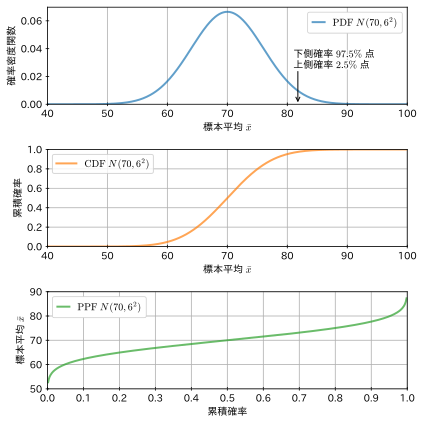

In [ ]:
#@title 図：PDF（確率密度）と CDF（累積確率）と PPF（累積確率の逆関数）の関係　{ display-mode: "form" }
%reset -f
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.patheffects as pe
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

mu, sigma = (70, 6) # 平均と標準偏差の設定
x_min, x_max = (40,100)
x = np.linspace(x_min, x_max, 400)
p = np.linspace(0, 1, 501)

fig,axes = plt.subplots(nrows=3, ncols=1, figsize=(6,6),facecolor='white')

# PDF 確率密度関数
ax = axes[0]
ax.plot(x, st.norm.pdf(x, loc=mu, scale=sigma), alpha=0.7, lw=2, label=f'$\\mathrm{{PDF}}\\; N\\,({mu}, {sigma}^2)$')
ax.set_xlabel('標本平均 $\\bar{x}$')
ax.set_ylabel('確率密度関数')
ax.set_xlim(x_min, x_max)
ax.set_ylim(0,)
ax.annotate('', xytext=(81.76, 0.025), xy=(81.76, 0), arrowprops=dict(arrowstyle='->'))
t = ax.text(81, 0.026, '下側確率 $97.5\\%$ 点\n上側確率 $2.5\\%$ 点')
t.set_path_effects([pe.Stroke(linewidth=3,foreground='white'),pe.Normal()])
ax.grid(axis='x')

# CDF 累積分布関数
ax = axes[1]
ax.plot(x, st.norm.cdf(x, loc=mu, scale=sigma), alpha=0.7, lw=2,label=f'$\\mathrm{{CDF}}\\; N\\,({mu}, {sigma}^2)$', c='tab:orange')
ax.set_xlabel('標本平均 $\\bar{x}$')
ax.set_ylabel('累積確率')
ax.set_xlim(x_min, x_max)
ax.set_yticks(np.arange(0,1.1,0.2))
ax.set_ylim(0,1)
ax.grid()

# PPF パーセント点関数
ax = axes[2]
ax.plot(p, st.norm.ppf(p, loc=mu, scale=sigma), alpha=0.7,  lw=2, label=f'$\\mathrm{{PPF}}\\; N\\,({mu}, {sigma}^2)$', c='tab:green')
ax.set_xlabel('累積確率')
ax.set_ylabel('標本平均 $\\bar{x}$')
ax.set_xticks(np.arange(0,1.1,0.1))
ax.set_xlim(0,1)
ax.set_yticks(range(50,90+1,10))
ax.set_ylim(50, 90)
ax.grid()

for ax in axes.ravel():
  ax.tick_params(axis='both', direction='inout')
  legend = ax.legend(handlelength=1.2, borderpad=0.5, framealpha=1)
  legend.get_frame().set_linewidth(0.75)

axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

ところで、このセクションの解説のはじめに、次のような仮定をしました。

> 標本の平均 $\bar{x}$ が、$N(70,\,6^2)$ の正規分布に従うことが分かっているものとします。

しかし、区間推定（信頼区間の計算）において、<font color="deeppink">実は上記の $\mu=70$ という情報は必要ありません</font>。区間推定に必要なのは $23.52\div2 = 11.76$ という値であって、これは（平均 $\mu$ とは無関係に） 分散 $\sigma^2=6^2$ によって決まる値となります。

事実、次のように $\mu$ を $0$ や $10$ に変化させても $95\%$信頼区間の幅 $23.52$ は変化しません。

In [ ]:
# 信頼区間の幅に母平均は無関係
%reset -f
import scipy.stats as st
for mu, sigma in [(0, 6),(100, 6)]:
  lower_95 = st.norm.ppf(0.025, loc=mu, scale=sigma)
  upper_95 = st.norm.ppf(0.975, loc=mu, scale=sigma)
  print(f'mu = {mu:3}, sigma = {sigma} の 95%信頼区間の幅は {upper_95 - lower_95:.2f}')

mu =   0, sigma = 6 の 95%信頼区間の幅は 23.52
mu = 100, sigma = 6 の 95%信頼区間の幅は 23.52


すなわち、以下のように分散 $\sigma^2$ さえ既知であれば、その情報から「$95\%$信頼区間」を求めることができるという性質があります。

> 標本の平均 $\bar{x}$ が、分散 $\sigma^2$ が $6^2$ の正規分布に従うことが分かっているものとします。

※ そもそも母平均 $\mu=70$ が既知ならば、母平均を推定する意味はありません🫠

では、ここまでの内容を踏まえて、教科書の問題を解いてみます。教科書 p.93 の【例題7.1】を以下に示します。


> ある県内の小学 $6$ 年男子の平均身長 $\mu$ を調べるため、$100$ 人を無作為に抽出したところ、標本平均は $144.8\, \mathrm{cm}$ であった。
>
> 過去のデータから、小学 $6$ 年男子の身長分布は標準偏差 $\sigma=7.14\, \mathrm{cm}$ の正規分布に従うと考えられるとき、この県の小学 $6$ 年生の平均身長の $\mu$ の $95\%$ 信頼区間を求めよ。

問題文から「母集団は正規分布に従い、**母集団の標準偏差** $\sigma$ は $7.14$ であること」が分かります。

そして、前回の **実験1** でも実証的に確認したように「$N(\mu,\, \sigma^2)$ の正規母集団からサイズ $n$ で標本抽出を繰り返すとき、その標本平均 $\bar{x}$ は $N(\mu,\, \sigma^2/n)$ に従うこと」が分かっています。

したがって、この【例題7.1】では「<font color='deeppink'>標本平均 $\bar{x}$ が、分散 $7.14^2/100$ （＝標準偏差 $7.14/10$）の正規分布に従うことが分かっている</font>」という状況になります。このとき、$95\%$信頼区間は、Python が使えるならば、次のように計算できます。

- 計算結果が教科書の解答例と一致することを確認してください。

In [ ]:
# 教科書 p.93【例題7.1】平均身長の95%信頼区間の計算
%reset -f
import scipy.stats as st

# 標本平均が従う正規分布の標準偏差
sigma = 7.14/10

lower_95 = st.norm.ppf(0.025, loc=0, scale=sigma) # 95%信頼区間の下側閾値
upper_95 = st.norm.ppf(0.975, loc=0, scale=sigma) # 95%信頼区間の上側閾値
# 👆 w の計算には影響しないので loc(=mu) の値は適当でよい。ここでは 0 を採用。

w = (upper_95-lower_95)/2 # 95%信頼区間の片側の幅
x = 144.8                 # 95%信頼区間の中央
print(f'95%信頼区間は [{x-w:.1f}, {x+w:.1f}] です。')

95%信頼区間は [143.4, 146.2] です。


In [ ]:
# 別解（scipy.stats.norm.intervalを利用して一発計算）
%reset -f
import scipy.stats as st
x = 144.8
sigma = 7.14/10
ci = st.norm.interval(loc=x, scale=sigma, confidence=0.95)
print(f'95%信頼区間は [{ci[0]:.1f}, {ci[1]:.1f}] です。')

95%信頼区間は [143.4, 146.2] です。


Python が利用できない環境では、次のように<font color='deeppink'>「標準誤差 $\mathrm{SE}$」を基準に $95\%$ 信頼区間を求めることができます</font>（教科書では、この方法で信頼区間を計算しています）。なぜ、この方法で適切に信頼区間が求められるか？$1.96$ という数字はどこからでてきたのか？については後述します。

<br>

$$ \left[\, \bar{x} - 1.96\cdot\mathrm{SE},\; \bar{x} + 1.96\cdot\mathrm{SE} \, \right]$$

<br>

ここで、標準誤差 $\mathrm{SE}$ の値は、母集団の分散 $\sigma^2$ が $7.14^2$、サンプルサイズ $n$ が $100$ であることから、次の理論式で求められます（これは、前回の「実験1」のなかの「補足実験」において確認しました）。

<br>

$$  標準誤差\, \mathrm{SE} = \frac{\sigma}{\sqrt{n}} = \frac{7.14}{\sqrt{100}} = \frac{7.14}{10}$$

<br>


これより、$95\%$信頼区間は、次のように計算できます。

<br>

$$ \left[\, \bar{x} - 1.96\cdot\frac{7.14}{10},\; \bar{x} + 1.96\cdot\frac{7.14}{10} \, \right]$$

<br>

ここで、標準誤差 $\mathrm{SE}$ に乗じている係数「<font color='deeppink'>$1.96$</font>」は、以下の図解のように **標準正規分布** $N(0,1)$ の中心から両側に $95\%$ の確率をカバーする値で、上側確率 $2.5\%$ 点 の値 $z_{\,0.025}$（$=1.96$） となります。通常、これは**標準正規分布の逆分布表**（教科書 p.142 の $\alpha=0.475$ の値）を参照して得ます。

また、<font color='deeppink'>$99\%$信頼区間</font> が要求される場合は、上側確率 $0.5\%$ 点 の値 $z_{\,0.005}=2.58$ を係数とします（教科書 p.142 の $\alpha=0.495$ の値を参照）



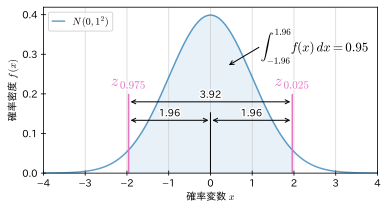

In [ ]:
#@title 図：標準正規分布の$95\%$信頼区間 { display-mode: "form" }
%reset -f
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.patheffects as pe
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

mu, sigma = (0, 1)
x_min, x_max = (-4,4)

x = np.linspace(x_min, x_max, 300)
pdf = st.norm.pdf(x, loc=mu, scale=sigma)

lower_95 = st.norm.ppf(0.025, loc=mu, scale=sigma)
upper_95 = st.norm.ppf(0.975, loc=mu, scale=sigma)

fig,ax = plt.subplots(figsize=(6,3),facecolor='white')

mask = (x >= lower_95) & (x <= upper_95)
x_fill = x[mask]
y_fill = pdf[mask]
ax.fill_between(x_fill, y_fill, color='tab:blue', alpha=0.1)

ax.plot(x, pdf, alpha=0.7, label=f'$N\\,({mu}, {sigma}^2)$')
ax.tick_params(axis='both', direction='inout', length=5)

base_h = 0.20
d = 0.02
ax.vlines(mu,ymin=0, ymax=base_h*2/3+d, color='k', lw=1)
ax.annotate('', xytext=(lower_95, base_h-d), xy=(upper_95, base_h-d),arrowprops=dict(arrowstyle='<->'))
t = ax.text(mu, base_h-d/2, f'{upper_95-lower_95:.2f}',ha='center')
t.set_path_effects([pe.Stroke(linewidth=3,foreground='white'),pe.Normal()])

for w in (lower_95, upper_95):

  if w == lower_95 :
    t = ax.text(w, base_h+d, '$z_{\\,0.975}$',ha='center', fontsize=16,c='tab:pink')
  else :
    t = ax.text(w, base_h+d, '$z_{\\,0.025}$',ha='center', fontsize=16,c='tab:pink')
  t.set_path_effects([pe.Stroke(linewidth=3,foreground='white'),pe.Normal()])

  ax.vlines(w,ymin=0, ymax=base_h, color='tab:pink', lw=1.5)
  ax.annotate('', xytext=(w, base_h*2/3), xy=(mu, base_h*2/3),arrowprops=dict(arrowstyle='<->'))
  t = ax.text( mu-(mu-w)/2, base_h*2/3+d/2, f'{abs(mu-w):.2f}',ha='center')
  t.set_path_effects([pe.Stroke(linewidth=3,foreground='white'),pe.Normal()])

ax.annotate('', xytext=(1.2, 0.32), xy=(0.4, 0.27),arrowprops=dict(arrowstyle='->'))
t = ax.text(1.2, 0.32, f'$\\int_{{{lower_95:.2f}}}^{{{upper_95:.2f}}}f(x)\\, dx=0.95$',va='center',fontsize=13)
t.set_path_effects([pe.Stroke(linewidth=3,foreground='white'),pe.Normal()])

ax.grid(axis='x',alpha=0.5)
ax.set_xlim(x_min, x_max)
ax.set_ylim(0,)
ax.set_xlabel('確率変数 $x$')
ax.set_ylabel('確率密度 $f\\,( x )$')
ax.legend(handlelength=1.2,loc='upper left')
plt.show()

Pythonでは、この $z_{\,0.025}$ を参照する方法でも$95\%$信頼区間の計算ができます。


In [ ]:
# 教科書 p.93【例題7.1】平均身長の95%信頼区間の計算（その2）
%reset -f
import scipy.stats as st

# ppf関数の引数は下側確率で与える必要があるので 1-0.025
z_0025 = st.norm.ppf(1-0.025)
# print(z_0025)       # => 1.959963984540054 ≒ 1.96
w = z_0025 * 7.14/10  # SE = 7.14/10
x = 144.8
print(f'95%信頼区間は [{x-w:.1f}, {x+w:.1f}] です。')

95%信頼区間は [143.4, 146.2] です。


## なぜ、$95\%$信頼区間が $\left[\, \bar{x} - 1.96\cdot\mathrm{SE},\; \bar{x} + 1.96\cdot\mathrm{SE} \, \right]$ で計算できるのか？

実は、標準正規分布 $N(0,1)$ の 上側確率 $2.5\%$ 点の値を $z_{\,0.025}$ としたとき、<font color='deeppink'>任意の平均 $\mu$ と分散 $\sigma^2$ を持つ正規分布 $N(\mu,\ \sigma^2)$ の 上側確率 $2.5\%$ 点の値</font> は、次式で計算できることが数学的に知られています（数学的な証明は教科書を参照してください）。

<br>

$$ \mu + z_{\,0.025}\cdot \sigma$$

<br>


同様に、$N(\mu,\ \sigma^2)$ の上側確率 $97.5\%$の点は $ \mu + z_{\,0.975}\cdot \sigma$ となります。

そして、上側確率 $2.5\%$ 点から $97.5\%$ 点までの区間幅（＝$95\%$信頼区間の幅）は、次のようになります。

- 信頼区間 =  CI: Confidence Interval

<br>

$$
\begin{aligned}
N(\,\mu,\, \sigma^2\,)\, の\, 95\%\mathrm{CI}\,の幅 =  &\; (\mu + z_{\,0.025}\cdot \sigma) - (\mu + z_{\,0.975}\cdot \sigma)  \\
 = &\; (z_{\,0.025}-z_{\,0.975})\,\sigma \\
 = &\; (1.96-(-1.96))\,\sigma \\
 = &\; 3.92\,\sigma
\end{aligned}
$$

<br>


いま、【例題7.1】において、標本平均 $\bar{x}$ は $N(\mu,\ \sigma^2)$ ではなく、$N(\mu,\, \sigma^2/n)$ に従うので、$95\%$信頼区間の幅は、次式のようになります。


<br>

$$ N(\,\mu,\,\frac{\sigma^2}{n}\,)\, の\, 95\%\mathrm{CI}\,の幅 = 3.92\ \cdot \frac{\sigma}{\sqrt{n}} $$


<br>

そして、信頼区間は $\bar{x}$ を中心に左右に均等に広がるので（$3.92/2=1.96$となるので）、$95\%$信頼区間は、次式のようになります。


<br>

$$ \left[\, \bar{x} - 1.96\cdot\frac{\sigma}{\sqrt{n}},\; \bar{x} + 1.96\cdot\frac{\sigma}{\sqrt{n}} \, \right]$$


<br>


ここで、$\sigma/\sqrt{n}$ は 標準偏差 $\mathrm{SE}$ なので、次式のようにも書けます。

<br>


$$ \left[\, \bar{x} - 1.96\cdot\mathrm{SE},\; \bar{x} + 1.96\cdot\mathrm{SE} \, \right]$$

<br>


以上が、$\left[\, \bar{x} - 1.96\cdot\mathrm{SE},\; \bar{x} + 1.96\cdot\mathrm{SE} \, \right]$ で$95\%$信頼区間が計算できる理由となります。

### **演習1a**

次の問題を Python を利用して解いてください。

- ここでは `scipy.stats.norm.interval` は**使用しない** でください。

（教科書 p.94【問7.2】より抜粋）

> ある県内の $15$ 歳男子の平均身長を調べるため、$400$ 人を無作為に標本抽出したところ、標本平均は $\overline{x}=168.2\,[\mathrm{cm}]$ であった。過去のデータから、$15$ 歳男子の身長の分布は標準偏差 $\sigma=5.95\,[\mathrm{cm}]$ の正規分布に従うと考えられるとき、次の問いに答えよ。
>
> (1) この県の 15歳男子の**平均身長** $\mu$ の信頼度 $95\%$ の信頼区間を求めよ。信頼限界は、小数第1位まで求めよ。

- 数値的な解答は教科書を参照してください。

In [ ]:
%reset -f
import scipy.stats as st

# ▼▼▼ 以下にコードを記述してください ▼▼▼

In [ ]:
#@title ⚠️演習1aの解答例（独自に問題に取り組んだ後で参照してください） { display-mode: "form" }
%reset -f
import scipy.stats as st

# ppf関数の引数は下側確率で与える必要があるので 1-0.025
z_0025 = st.norm.ppf(1-0.025)
w = z_0025 * 5.95/(400**0.5)
x = 168.2
print(f'95%信頼区間は [{x-w:.1f}, {x+w:.1f}] です。')

95%信頼区間は [167.6, 168.8] です。


### **演習1b**

次の問題を Python を利用して解いてください。

- ここでは `scipy.stats.norm.interval` を**使用して** ください。

（教科書 p.102【練習問題7 [1]】より抜粋）

> ある県内の $15$ 歳男子の平均体重を調べるため、$100$ 人を無作為標本抽出したところ、標本平均は $60.3\,\mathrm{kg}$ であった。過去のデータから、$15$ 歳男子の体重分布は $\sigma=9.86\,\mathrm{[kg]}$ の正規分布に従うと考えられるとき、その県内の $15$ 歳男子の平均体重 $\mu$ の信頼度 $95\%$、$99\%$ の信頼区間を求めよ。信頼限界は、小数第 $1$ 位までを求めよ。

- 数値的な解答は教科書を参照してください。

In [ ]:
%reset -f
import math
import scipy.stats as st

# ▼▼▼ 以下にコードを記述してください ▼▼▼

In [ ]:
#@title ⚠️演習1bの解答例（独自に問題に取り組んだ後で参照してください） { display-mode: "form" }
%reset -f
import math
import scipy.stats as st

floor = lambda x,n : f'{math.floor(x * 10 ** n) / (10 ** n):.{n}f}' # 小数n桁で切り捨て
ceil  = lambda x,n : f'{math.ceil(x * 10 ** n) / (10 ** n):.{n}f}'  # 小数n桁で切り上げ

n = 100       # サンプルサイズ
x = 60.3      # 標本平均
sigma = 9.86  # 母集団の標準偏差
for c in [0.95, 0.99]:
  ci = st.norm.interval(loc=x, scale=sigma/n**0.5, confidence=c)
  print(f'{c*100:.0f}%信頼区間は [{floor(ci[0],1)}, {ceil(ci[1],1)}] です。')

95%信頼区間は [58.3, 62.3] です。
99%信頼区間は [57.7, 62.9] です。


# **ここまでを整理**

1. 標本 $\mathrm{S}$ から母集団 $\Omega$ の平均 $\mu$ を区間推定したい。
2. 標本平均 $\bar{x}$ が、どのような確率分布に従うかが分かれば区間推定可能である。
    - 例えば、標本平均 $\bar{x}$ が $\mathrm{N}(\mu,\sigma^2)$ に従うことが分かれば区間推定できた。
    - 実は、標本平均 $\bar{x}$ が $\mathrm{N}(?,\sigma^2)$ に従うという情報だけでも区間推定できることがわかった。

## **母分散** $\sigma^2$ **が不明な場合**

ここまでは、母分散（母集団の分散）$\sigma^2$ が**既知である場合**を考えてきました。しかし、実際には母分散 $\sigma^2$ が既知であることは稀です。

母平均 $\mu$ の区間推定は、<font color='deeppink'>標本平均 $\bar{x}$ が特定の確率分布に従うことを前提
</font> としています。したがって、母分散 $\sigma^2$ が未知である場合、標本平均が「標準誤差 $\sigma/\sqrt{n}$ をもつ正規分布に従う」という前提が成立せず、区間推定ができません。

このような場合に利用されるのが、$t$ 統計量になります。前回の「実験3」では、母分散 $\sigma^2$ に依存せず、次の関係が成り立つことを実証的に確認しました。


> 各標本（$i = 1, 2, \cdots,\infty$）について、標本平均 $\bar{x}$ と不偏標準偏差 $u$ から、次のような統計量 $t$ を計算すると...
>
> $$ t = \frac{\bar{x} - \mu}{u/\sqrt{n}} $$
>
> $t$ は、自由度 $n-1$ の <font color="deeppink">$t$ 分布</font> に従う。



この関係を逆に捉えると、<font color='deeppink'>「自由度 $n-1$ の $t$ 分布」における上側確率 $2.5\%$ の点を $t_{\,0.025}$ から、元の分布（＝標本平均 $\bar{x}$ の分布）の上側確率 $2.5\%$ 点 $\bar{x}_{\,0.025}$ を求められる</font> といえます。

すなわち、標本平均 $\bar{x}$ の分布における上側確率 $2.5\%$ の点 $\bar{x}_{\,0.025}$ は、次のように計算できます。

<br>

$$ \bar{x}_{\,0.025} = t_{\,0.025} \cdot \frac{u}{\sqrt{n}} + \mu $$

<br>


同様に、上側確率 $97.5\%$ の点 $\bar{x}_{\,0.975}$ は、次のようになります。

<br>


$$ \bar{x}_{\,0.975} = t_{\,0.975} \cdot \frac{u}{\sqrt{n}} + \mu $$

<br>


これより、$95\%$信頼区間の「幅」は、次のようになります。

<br>

$$ \bar{x}_{\,0.025} - \bar{x}_{\,0.975} = ( t_{\,0.025} - t_{\,0.975})  \cdot \frac{u}{\sqrt{n}} $$

<br>


ところで、$t$ 分布は、次のような左右対称な形状であり、$  t_{\,0.025} - t_{\,0.975} =
 2\cdot t_{\,0.025} $ と表すことができます。

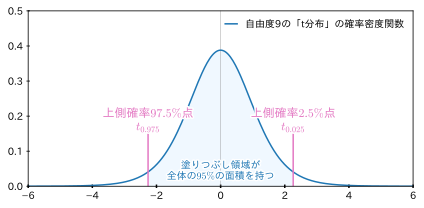

In [ ]:
#@title 区間推定に使用する t値（95%）の例 { display-mode: "form" }
%reset -f
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

# 確率密度関数 PDF: Probability Density Function
# 累積確率分布関数 CDF: Cumulative Distribution Function

fig,ax = plt.subplots(figsize=(6,3),facecolor='white')

n = 10
x = np.linspace(-6, 6, 300)
t_dist_pdf = scipy.stats.t.pdf(x, df=n-1)  # 確率密度関数 PDF

ax.axvline(0,c='gray',lw=0.5, alpha=0.7)

# 確率密度関数の描画
ax.plot(x, t_dist_pdf, color='tab:blue', lw=1.5,label=f'自由度{n-1}の「t分布」の確率密度関数')

# 累積確率 0.025 〜 0.975 に対応する t値を取得
t_lower = scipy.stats.t.ppf(0.025, df=n-1)
t_upper = scipy.stats.t.ppf(0.975, df=n-1)

for t in [(t_lower,97.5), (t_upper,2.5)]:
  ax.vlines(t[0],ymin=0,ymax=0.15,color='tab:pink',lw=1.5)
  text=ax.text(t[0],0.16,f'上側確率${t[1]}\%$点\n$t_{{{t[1]/100:.3f}}}$',ha='center',c='tab:pink',fontsize=12)
  text.set_path_effects([pe.Stroke(linewidth=3, foreground='white'), pe.Normal()])

# 塗りつぶす範囲（t_left 〜 t_right）
mask = (x >= t_lower) & (x <= t_upper)
x_fill = x[mask]
y_fill = t_dist_pdf[mask]

text=ax.text(0,0.02,f'塗りつぶし領域が\n全体の$95\%$の面積を持つ',ha='center',c='tab:blue')
text.set_path_effects([pe.Stroke(linewidth=3, foreground='white'), pe.Normal()])

# 塗りつぶし
ax.fill_between(x_fill, y_fill, color='aliceblue')

# 軸設定など
ax.set_xlim(-6, 6)
ax.set_ylim(0, 0.5)
ax.tick_params(axis='x', direction='inout', width=1.5)
ax.tick_params(axis='y', direction='inout')
ax.legend(handlelength=1.2, frameon=False)

plt.tight_layout()
plt.show()

そのため$95\%$信頼区間の幅は、次のようになります。

<br>

$$ \bar{x}_{\,0.025} - \bar{x}_{\,0.975} =( t_{\,0.025} - t_{\,0.975})  \cdot \frac{u}{\sqrt{n}}= 2\cdot t_{\,0.025} \cdot \frac{u}{\sqrt{n}} $$

<br>

そして、$95\%$信頼区間は $\bar{x}$ を中心に左右に均等に広がるので、次のようになります。

<br>

$$ \left[\, \bar{x} -  t_{\,0.025}  \cdot \frac{u}{\sqrt{n}},\; \bar{x} +  t_{\,0.025}  \cdot \frac{u}{\sqrt{n}} \, \right]$$

<br>

ここで、$ u/\sqrt{n}$ は、前回の「実験1」で確認したように「**標準誤差** $\mathrm{SE}$ **の推定式**」 となるので、次のように書くことができます。

<br>

$$ \left[\, \bar{x} -  t_{\,0.025}  \cdot \mathrm{SE},\; \bar{x} +  t_{\,0.025}  \cdot \mathrm{SE} \, \right]$$

<br>

なお、「自由度の $n-1$ の $t$ 分布」の $t_{\,0.025}$ は、Pythonプログラムでは、次のように求めることができます。例えば、自由度 $9$ の $t_{\,0.025}$ は $2.262$ になります。

In [ ]:
# 自由度 n-1 の t分布 の上側確率2.5%点の値を求めるプログラム
%reset -f
import scipy.stats as st
n = 10     # サンプルサイズ
p = 0.025  # 上側確率 2.5%

# 第1引数は「下側確率」で与える必要があるので 1-p を与える
# 第2引数は「自由度」を与える
t_0025 = st.t.ppf(1-p, df=n-1)
print(f'{t_0025:.3f}')

# 出力例（自由度9の場合）
# 2.262

2.262


Pythonが使えないときは、教科書 p.144 の $t$ 分布表 の $n=9$、$\alpha=0.050$ を参照します。

### **演習2**

（教科書 p.95【例題7.2】より抜粋）

ある健康食品から $10$ 個の標本を無作為抽出し、含まれるビタミンCの含有量を調べたところ、その平均値は $\overline{x}=30.3$で、不偏分散の値は $u^2=1.7^2$ であった。この健康食品のビタミンCの平均含有量 $\mu$ の $95\%$ 信頼区間を求めよ。ただし、ビタミンCの含有量は、正規分布に従うとし、信頼限界は小数第 $1$ 位まで求めよ。

- 数値的な解答は教科書を参照してください。
- ここでは `scipy.stats.t.interval` は**使用しないこと**。


In [ ]:
%reset -f
import math
import scipy.stats as st

# ▼▼▼ 以下にコードを記述してください ▼▼▼

In [ ]:
#@title ⚠️演習2の解答例（独自に問題に取り組んだ後で参照してください） { display-mode: "form" }
%reset -f
import math
import scipy.stats as st

floor = lambda x,n : f'{math.floor(x * 10 ** n) / (10 ** n):.{n}f}' # 小数n桁で切り捨て
ceil  = lambda x,n : f'{math.ceil(x * 10 ** n) / (10 ** n):.{n}f}'  # 小数n桁で切り上げ

n, x, u = (10, 30.3, 1.7)  # サンプルサイズn、標本平均x、不偏標準偏差u

p = 0.025     # 上側確率 2.5%（信頼係数95％）
se = u/n**0.5 # 標準誤差
t_0025 = st.t.ppf(1-p, df=n-1)
print(f'95%信頼区間は [ {floor(x-t_0025*se,1)} , {ceil(x+t_0025*se,1)} ] です。')

95%信頼区間は [ 29.0 , 31.6 ] です。


### **演習3**

（教科書 p.96【問7.3】より抜粋）

> あるメーカーのドライヤーが故障するまでの期間を、$8$ 台のドライヤーで無作為に選び調べたところ、平均 $7.8$ 年、標本分散 $9.1$ であった。このとき、このドライヤーが故障するまでの期間の母平均 $\mu$ の信頼区間を、信頼度 $95\%$、$99\%$ でそれぞれ求めよ。
>
> ただし、ドライヤーが故障するまでの期間は正規分布に従うものとし、信頼限界は小数第 $1$ 位まで求めよ。

- 数値的な解答は教科書を参照してください。
- ここでは `scipy.stats.t.interval` を**使用すること**。
- ヒント
$$ 標本分散 \;s^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2 $$
$$ 不偏分散 \;u^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2 $$
$$ 標準偏差（推定値）\;\mathrm{SE}= \frac{u}{\sqrt{n}} $$


In [ ]:
%reset -f
import math
import scipy.stats as st

# ▼▼▼ 以下にコードを記述してください ▼▼▼

In [ ]:
#@title ⚠️演習3の解答例（独自に問題に取り組んだ後で参照してください） { display-mode: "form" }
%reset -f
import math
import scipy.stats as st

floor = lambda x,n : f'{math.floor(x * 10 ** n) / (10 ** n):.{n}f}' # 小数n桁で切り捨て
ceil  = lambda x,n : f'{math.ceil(x * 10 ** n) / (10 ** n):.{n}f}'  # 小数n桁で切り上げ

n = 8       # サンプルサイズ
x = 7.8     # 標本平均

s2 = 9.1        # 標本分散
u2 = s2*n/(n-1) # 不偏分散
u  = u2**0.5  # 不偏標準偏差（母集団の標準偏差の推定値）

for c in [0.95, 0.99]:
  ci = st.t.interval(df=n-1, loc=x, scale=u/n**0.5, confidence=c)
  print(f'{c*100:.0f}%信頼区間は [{floor(ci[0],1)}, {ceil(ci[1],1)}] です。')

95%信頼区間は [5.1, 10.5] です。
99%信頼区間は [3.8, 11.8] です。


## **ここまでの内容を整理**

母集団 $\Omega$ から、サンプルサイズ $n$ で無作為抽出した標本 $\mathrm{S}$ がある。

その標本平均が $\bar{x}$、不偏標準偏差 が $u$ であるとき、母平均 $\mu$ の「 $95\%$信頼区間」は...

- 母分散 $\sigma$ が<font color='deeppink'>既知</font>であれば、標準正規分布 $N(0,1)$ の上側確率 $2.5\%$ の点の値 $z_{\,0.025}$（＝<font color='deeppink'>$1.96$</font>）を用いて次式で求められる。

$$ \left[\, \bar{x} -  z_{\,0.025}  \cdot \frac{\sigma}{\sqrt{n}},\; \bar{x} +  z_{\,0.025}  \cdot \frac{\sigma}{\sqrt{n}} \, \right] (\, = \left[\, \bar{x} -  z_{\,0.025}  \cdot \mathrm{SE},\; \bar{x} +  z_{\,0.025}  \cdot \mathrm{SE} \, \right] \,)$$


- 母分散 $\sigma$ が<font color='deeppink'>未知</font>であれば、自由度 $n-1$ の $t$ 分布の上側確率 $2.5\%$ の点の値 $t_{\,0.025}$ を用いて次式で求められる。

$$ \left[\, \bar{x} -  t_{\,0.025}  \cdot \frac{u}{\sqrt{n}},\; \bar{x} +  t_{\,0.025}  \cdot \frac{u}{\sqrt{n}} \, \right] (\, = \left[\, \bar{x} -  t_{\,0.025}  \cdot \mathrm{SE},\; \bar{x} +  t_{\,0.025}  \cdot \mathrm{SE} \, \right]\,)$$

#### **演習**

上記の内容を「$99\%$信頼区間」に書き換えた内容をテキストセルに記述せよ。

# **「95%信頼区間」という言葉の意味**（よくある誤解・再掲）

信頼区間に関して**よくある誤解**として、次のようなものがあります。

> $95\%$ の確率で、この区間内に母平均 $\mu$ が存在している

これは直感的で、一見正しく思える解釈となります。しかし、確率的に変動するのは「**母平均**」ではなく「**信頼区間の方**」です。母平均 $\mu$ は未知ではあるものの、ある $1$ つの固定された値であり、ランダムに動くわけではありません。

正しい理解は、次のようになります。

> 同じ手法で母集団から何度もサンプリングし、そのたびに信頼区間を計算したとしたら、得られた区間全体のうち $95\%$ が真の母平均 $\mu$ を含むはずである

これは、信頼区間の解釈が「長期的な頻度」に基づくことを意味しています。いま手元にある $1$ つの信頼区間が真の値を含んでいるかは分かりませんが、同じ手続きで求められた信頼区間全体を通してみれば、そのうち $95\%$ が真の値を含む、という保証があります。




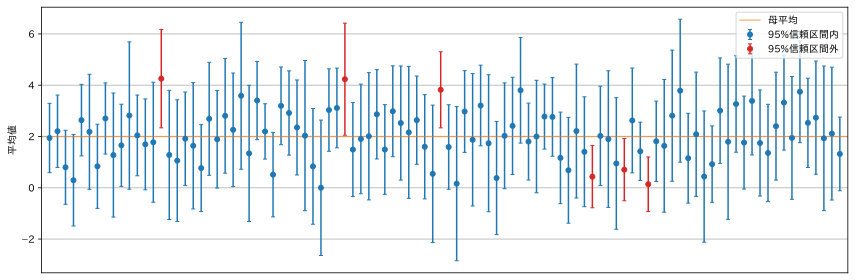

母集団平均: 1.9989
95%信頼区間内に母平均を含む標本数: 94/100 (94.0%)


In [ ]:
#@title 95%信頼区間の意味を理解するための補足実験 { display-mode: "form" }
%reset -f

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as tk
import japanize_matplotlib
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

# 母集団の生成
# - 母集団の分布の切替えて実験してみてください
# - 母集団のばらつき scale を変化させて実験してみてください
population = np.random.normal(loc=2,scale=3,size=5_000_000)
mu = population.mean() # 母平均を計算

# 無作為抽出 n と m を変化させて実験してみてください
n = 10   # サンプルサイズ
m = 100  # サンプリング回数
samples = np.random.choice(population, size=(m,n), replace=True)

# 標本平均の計算
sample_means = np.mean(samples, axis=1)

# 各標本の不偏標準偏差を計算
sample_stds = np.std(samples, axis=1, ddof=1)

# 標準誤差SEを計算
standard_errors = sample_stds / np.sqrt(n)

# t分布の臨界値を計算（95%信頼区間）
alpha = 0.05  # 有意水準
p = 1 - alpha / 2 # 累積確率 97.5%（上側2.5%点）
t = st.t.ppf(p, df=n-1)

# 95%信頼区間の幅を計算
ci = t * standard_errors

fig, ax = plt.subplots(figsize=(12, 4), facecolor='white', dpi=150)

# 信頼区間に母集団平均が含まれるかどうかのマスクを作成
in_ci_mask = (sample_means - ci <= mu) & (mu <= sample_means + ci)
out_ci_mask = ~in_ci_mask

# 信頼区間が母平均を含む場合を青で描画
ax.errorbar(np.arange(m)[in_ci_mask], sample_means[in_ci_mask], yerr=ci[in_ci_mask],
            capsize=2, ecolor='tab:blue', markerfacecolor='tab:blue', markeredgecolor='tab:blue',
            linestyle='none', marker='o', markersize=5, label='95%信頼区間内')

# 信頼区間が母平均を含まない場合を赤で描画
ax.errorbar(np.arange(m)[out_ci_mask], sample_means[out_ci_mask], yerr=ci[out_ci_mask],
            capsize=2, ecolor='tab:red', markerfacecolor='tab:red', markeredgecolor='tab:red',
            linestyle='none', marker='o', markersize=5, label='95%信頼区間外')

# 母平均の描画
ax.axhline(mu, color='tab:orange', label='母平均',alpha=0.5)

# グラフの設定
ax.set_ylabel('平均値')
ax.set_xticks([])
ax.set_xlim(-1,m)
ax.grid(axis='y')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# 信頼区間に母平均を含む標本数をカウント
covered_count = sum(in_ci_mask)

print(f"母集団平均: {mu:.4f}")
print(f"95%信頼区間内に母平均を含む標本数: {covered_count}/{m} ({covered_count/m*100:.1f}%)")

# **統計的仮説検定の導入**

ここまでが十分に理解できれば、以下の **報告3（Lv.3）** までを行なうことができるようになっているはずです。

<br>


Aさんは、あるSNSのUI設計および実装を担当している。いま、新しいUIを開発し、これを無作為に抽出した $50$ 名のユーザに適用し、適用前後における $1$ 日あたりの平均コンテンツ閲覧数の変化を観測した。

▼ 報告1（Lv.1）▼

> 新UI の適用により、ユーザ $1$ 人あたりの $1$ 日あたり平均コンテンツ閲覧数は、適用前と比較して平均で $5.5$ 件増加した。

▼ 報告2（Lv.2）▼

> 新UI の適用により、ユーザ $1$ 人あたりの $1$ 日あたり平均コンテンツ閲覧数は、適用前と比較して平均で $5.5$ 件増加した。差の標準誤差は $3.4$ 件であった。

▼ 報告3（Lv.3）▼

> 新UI の適用により、ユーザ $1$ 人あたりの $1$ 日あたり平均コンテンツ閲覧数は、適用前と比較して平均で $5.5$ 件増加した。差の $95\%$信頼区間は $[\,−1.4,\;12.4\,]$ 件と推定された。

<br>

ここからは、さらに踏み込んで以下のような報告ができるように「**統計的仮説検定**」という手法を学んでいきます。

<font color='deeppink'>▼ 報告4（Lv.4） ▼</font>

> <font color='deeppink'>新UI の適用による効果を評価するため、適用前後の $1$ 日あたり平均コンテンツ閲覧数の差に対して対応のある $t$ 検定を実施した。その結果、有意差は確認されなかった（ $t\,(49) = 1.62,\; p = 0.112$ ）。</font>

▼ 報告5 （参考）▼

> 新UI の適用による効果について、ユーザごとの適用前後の平均コンテンツ閲覧数の差に対し対応のある $t$ 検定を実施した。その結果、有意差は確認されなかった（ $t\,(49) = 1.62,\; p = 0.112$ ）。効果量（Cohen' s d）は約 $0.23$ と算出され、小さい効果に相当する。また、事前に想定された検出力（$\alpha = 0.05$、片側検定）に対して、このサンプルサイズでは検出力は約 $0.28$ と推定され、検出力不足の可能性がある。




# **<font color="deeppink">目的4</font>**

母平均 $\mu$ の検定（$t$ 検定・$z$ 検定）について、Python を用いたシミュレーション実験を通じて実証的に確認し、その理解を深める。


# **統計的仮説検定**

ここまでは、手元の標本から**母数**（例えば、母平均 $\mu$ や 母分散 $\sigma$ など） **を推定すること** を主な目的としてきました。

ここからは、この関係を逆に捉え、<font color='deeppink'>母数の値を仮定したうえで、手元にあるような標本が得られる確率（可能性）に注目する「**検定**（統計的仮説検定）」という手法</font>を学んでいきます。言い換えれば、母数に関する仮説を立て、その仮説が「どれほど妥当であるか」を標本データを基に検討していくことになります。

具体的には、「推定」と「検定」には次のような違いがあります。

> **推定** : 高専4年生の $1$ 日あたりの授業時間外の学習時間の平均 $\mu$ を知りたい。そこで、無作為に抽出した標本から母平均 $\mu$ を推定（点推定・区間推定）する。

> **検定** : 高専4年生の $1$ 日あたりの授業時間外の学習時間の平均 $\mu$ が $130$ 分より長いことを検証したい。そのため、あえて $\mu=130$ という帰無仮説を設定し、それが手元の標本と矛盾するかどうかを通じて、間接的に $\mu > 130$ を導き出す。





## **仮説検定の定型的な解き方**


仮説検定が数学の問題として出題されるときは、**あらかじめ定められた手順（枠組み）に従って、定型的に処理することが求められます**。ここでは、まず「検定」の基本的な手順を確認し、その後に原理的な背景について詳しく解説していきます。

次のような問題を考えます。

> あるウェブアプリのビルド時間は、CI/CDパイプラインの実行履歴から平均 $45.2$ 秒であることが確認されている。いま、ビルドオプションを変更した結果、$18$ 回の実行で測定したビルド時間は平均 $43.4$ 秒、不偏標準偏差は $3.93$ 秒となった。
>
> **ビルドオプションの変更によってビルド時間が変化したといえるか**（統計的に有意な変化があったといえるか）、**<font color="deeppink">有意水準 $5\%$ で両側検定</font>** せよ。

検定は、次のような手順で実行します。

#### **1. 検定の目的確認、帰無仮説と対立仮説の設定**

ビルド時間を $\mu$ として、それに変化が生じたかどうかを検証するため、以下のような2つの仮説を設定します。

- 帰無仮説　$\mathrm{H}_0: \mu = 45.2$
- 対立仮説　$\mathrm{H}_1: \mu \ne 45.2$

<br>

#### **2. 検定統計量の導出と数値代入**

母分散が未知であるため、$t$ 検定を利用する方針をとります。統計量 $t$（$t$ 値）は、次のように計算できます。

<br>

$$
t = \frac{\bar{x} - \mu}{\mathrm{SE}} = \frac{\bar{x} - \mu}{u / \sqrt{n}}
$$

問題文では、以下の値が与えられています。

- 標本平均 $\bar{x} = 43.4$
- 不偏標準偏差 $u = 3.93$
- 標本サイズ $n = 18$
- 母平均（帰無仮説 $\mathrm{H}_0$）$\mu = 45.2$

これより標本平均 $\bar{x}$ の「標準誤差 $\mathrm{SE}$」および「$t$ 値」は、次のようになります。

<br>

$$ \mathrm{SE} = \frac{u}{\sqrt{n}} = \frac{3.93}{\sqrt{18}} \fallingdotseq 0.926 $$

$$ t = \frac{\bar{x} - \mu}{\mathrm{SE}}  = \frac{43.4 - 45.2}{\mathrm{SE}} \fallingdotseq -1.800 $$

In [ ]:
%reset -f
import scipy.stats as st
SE = 3.93/18**0.5
t  = (43.4-45.2)
print(f'SE =  {SE:.3f}',f't  = {t:.3f}',sep='\n')

SE =  0.926
t  = -1.800


#### **3. 臨界値の算出と棄却域の設定**

帰無仮説 $\mathrm{H}_0$ が正しいとすれば、$t$ 値は自由度 $n - 1 = 17$ の $t$ 分布に従います。

有意水準 $5\%$ で両側検定を行うため、上側確率 $2.5\%$ 点の臨界値 $t_{\,0.025}$ を用いて帰無仮説 $\mathrm{H}_0$ の**棄却域**を求めます。

まず、$t_{\,0.025}$ は、$t$ 分布の逆関数表 (教科書 p.144) から次のように求められます。

<br>

$$ t_{\,0.025} \fallingdotseq 2.110 $$

<br>

これより、帰無仮説 $\mathrm{H}_0$ の棄却域は次のように定まります。

<br>

$$ |t| > 2.110 $$

In [ ]:
# Python で t_0.025 を求める場合
%reset -f
import scipy.stats as st
n = 18     # サンプルサイズ
p = 0.025  # 上側確率
t_0025 = st.t.ppf(1-p, df=n-1)
print(f't_0025 = {t_0025:.3f}')

t_0025 = 2.110


#### **4. 統計量と臨界値の比較による判断**

標本から計算した $t$ 値は $-1.800$ であり、その絶対値は次のようになります。

<br>

$$ |t| \approx 1.800 \leq 2.110 \;（\, |t| > 2.110 \,とはならない\,）$$

<br>

これより、次のように結論を得ます。

> 帰無仮説 $\mathrm{H}_0: \mu = 45.2$（ビルド時間に変化はない）は <font color='deeppink'>棄却されない</font>。すなわち「<font color='deeppink'>ビルドオプションの変更によってビルド時間が変化したとは（統計的に）言えない</font>」（有意水準 $5\%$ において）。




#### **4'. 統計量と臨界値の比較による判断（仮に $t$ が $-2.300$ であった場合）**

標本から計算した $t$ 値は $-2.300$ であり、その絶対値は次のようになります。

$$ |t| \approx 2.300 > 2.110 $$

これより、次のように結論を得ます。

> 帰無仮説 $\mathrm{H}_0: \mu = 45.2$（ビルド時間に変化はない）は <font color='deeppink'>棄却される</font>。すなわち「<font color='deeppink'>ビルドオプションの変更により、ビルド時間には統計的に有意な変化があったと結論づけられる</font>」（有意水準 $5\%$ において）。

## **「検定の原理」について理解する**

検定の「原理」や「考え方」について、具体例を使って理解を深めていきます。

<br>

例として「**高専生の** $1$ **日あたりの授業時間外の学習時間の平均は** $130$ **分である**」という仮説と、高専4年生から無作為抽出した「サンプルサイズ $n$ が $16$、標本平均 $\bar{x}$ が $140$、不偏標準偏差 $u$ が $36$ の学習時間の標本 $\mathrm{S}$」があるとします。

このとき、

1. 「母平均 $\mu$ が $130$ である」という主張を仮説 $\mathrm{H}_{0}$ とします。無作為抽出で得た標本 $\mathrm{S}$ を使って、この仮説 $\mathrm{H}_{0}$ が「どれほど妥当なものか」を考えていきます。以下、「<font color='deeppink'>仮説 $\mathrm{H}_{0}$ が正しい</font>」という前提でしばらく議論を進めていきます。
    - 仮説：Hypothesis（ハイポセシス）
2. 仮説 $\mathrm{H}_{0}$ が正しい前提で、母集団 $\Omega$ から無作為抽出を繰り返したときに得られる標本の標本平均 $\bar{x}$ の確率分布を考えます。
    - ここで、「母集団 $\Omega$ が正規分布に従うとき」もしくは「サンプルサイズ $n$ が十分大きいとき」に、$\bar{x}$ は正規分布 $N(\mu,\,\sigma^2/n)$ に従うという性質を利用します。この性質は、前回の「実験1」で実証的に確認しました。
    - 教科書 p.81 の【6.4 正規母集団の標本平均の分布】、p.82 の【6.5 中心極限定理】のように数学的に証明されていています。
3. 母集団 $\Omega$ の母分散 $\sigma^2$ は未知なので、標本 $\mathrm{S}$ の不偏標準偏差 $u$ から母分散 $\sigma^2$ を点推定し、これより、標本平均 $\bar{x}$ の確率分布は次のようになります。

<br>

$$ N(\mu,u^2/n) = N(130,36^2/16) = N(130,9^2) $$

<br>

4. この $N(130,9^2)$ を図示すると次のようになります。
    - 仮説 $\mathrm{H}_{0}$（$\mu=130$）が正しいとすれば、そのような母集団 $\Omega$ から抽出を繰り返えせば、標本平均 $\bar{x}$ は次のような確率分布に従うはずです。

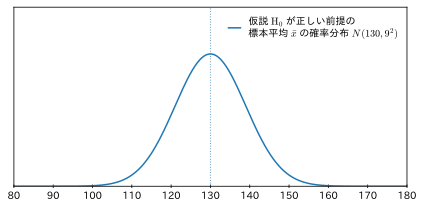

In [ ]:
#@title 仮説 $\mathrm{H}_{0}$ に基づく標本平均 $\bar{x}$ の確率分布 { display-mode: "form" }
%reset -f
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

# 標本
n = 16 # サンプルサイズ
x_bar = 150
u = 36

# 母平均 mu は仮説H0から、sigma は標本の不偏分散 u から推定
mu, sigma = (130, u**2/n)

# 標本平均 $\bar{x}$ の分布を描画
fig,ax = plt.subplots(figsize=(6,3),facecolor='white')

# 標準誤差（＝標本平均の標準偏差）は u/n**0.5
se = u/n**0.5
x = np.linspace(0, 400, 1201)
norm_dist_pdf = st.norm.pdf(x, loc=mu, scale=se)

# 確率密度関数の描画
ax.plot(x, norm_dist_pdf, color='tab:blue', lw=1.5,
        label=f'仮説 $\\mathrm{{H}}_{{0}}$ が正しい前提の\n標本平均 $\\bar{{x}}$ の確率分布 $N\\,({mu},{se:.0f}^2)$')
ax.axvline(mu, c='tab:blue', lw=1, ls=':', alpha=0.7)

# # 軸設定など
x_min, x_max = 80, 180
y_max = 0.06
ax.set_ylim(0, y_max)
ax.set_xlim(x_min,x_max)
ax.set_yticks([])
ax.set_xticks(np.arange(x_min,x_max+1,10))
ax.tick_params(axis='x', direction='inout')
ax.legend(handlelength=1.2, frameon=False)

plt.tight_layout()
plt.show()

5. 次に、区間推定の考え方を適用し、標本平均 $\bar{x}$ の「$95\%$ 信頼区間」を求めていきます。いま母分散 $\sigma^2$ は未知なので、$\mu = 130$ を中心とする「$95\%$信頼区間」は、自由度 $n-1$ の「$t$ 分布」を用いて、次のように求められます。

<br>

$$ \left[\, \mu -  t_{\,0.025}  \cdot \mathrm{SE},\; \mu +  t_{\,0.025}  \cdot \mathrm{SE} \, \right]$$

<br>

6. ここで、 $t_{\,0.025}$ は、自由度 $n-1 = 15$ の $t$ 分布の上側確率 $2.5\%$ 点の値（教科書 p.144 ）であり、次のように得られます。

<br>

$$ \left[\, \mu -  2.131 \cdot \mathrm{SE},\; \mu +  2.131  \cdot \mathrm{SE} \, \right]$$



In [ ]:
# 自由度15の上側確率 $2.5\%$ 点 $t_{\,0.025}$
%reset -f
import scipy.stats as st
n = 16
p = 0.025     # 上側確率 2.5%（信頼係数95％）
t_0025 = st.t.ppf(1-p, df=n-1) # => 2.131449545559323
print(f't_0025 = {t_0025:.3f}')

t_0025 = 2.131


7. また、標準誤差 $\mathrm{SE}$ は、標本 $\mathrm{S}$ の不偏標準偏差 $u$ とサンプルサイズ $n$ から次のように推定します。

<br>

$$ \mathrm{SE}=\frac{u}{\sqrt{n}} = \frac{36}{\sqrt{16}} = \frac{36}{4}
 = 9$$

<br>


8. 標本平均 $\bar{x}$ の確率分布に、$95\%$信頼区間を重ねると次のようになります。

<br>


$$ \left[\, \mu -  2.131 \cdot \mathrm{SE},\; \mu +  2.131  \cdot \mathrm{SE} \, \right] = \left[\, 130 -  2.131 \cdot 9,\; 130 +  2.131  \cdot 9 \, \right] = \left[\, 110.82,\; 149.18 \, \right]$$

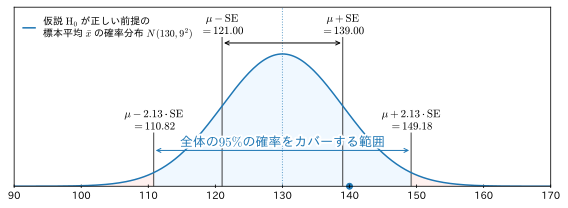

In [ ]:
#@title 仮説 $\mathrm{H}_{0}$ に基づく標本平均 $\bar{x}$ の確率分布に信頼区間を重ねる { display-mode: "form" }
%reset -f
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

# 標本
n = 16 # サンプルサイズ
x_bar = 150
u = 36

# 母平均 mu は仮説H0から、sigma は標本の不偏分散 u から推定
mu, sigma = (130, u**2/n)

# 標本平均 $\bar{x}$ の分布を描画
fig,ax = plt.subplots(figsize=(8,3),facecolor='white')

# 標準誤差（＝標本平均の標準偏差）は u/n**0.5
se = u/n**0.5
x = np.linspace(0, 400, 1201)
norm_dist_pdf = st.norm.pdf(x, loc=mu, scale=se)


# mu ± SE の描画
d = 0.002
ah = 0.048
ax.vlines([mu-se,mu+se],ymin=0,ymax=ah+d, color='black', lw=0.75)
ax.annotate('', xytext=(mu-se, ah), xy=(mu+se, ah),arrowprops=dict(arrowstyle='<->'),c='tab:blue')
for w in [(se,'+'),(-se,'-')]:
  t = ax.text( mu+w[0], ah+d*1.5, f'$\\mu{w[1]}\\mathrm{{SE}}$\n$={mu+w[0]:.2f}$',ha='center',fontsize=11)
  t.set_path_effects([pe.Stroke(linewidth=5,foreground='white'),pe.Normal()])

# mu ± t・SE の描画
t_0025 = st.t.ppf(1-0.025, df=n-1)

mask = (x >= mu-t_0025*se) & (x <= mu+t_0025*se)
x_fill = x[mask]
y_fill = norm_dist_pdf[mask]
ax.fill_between(x_fill, y_fill, color='aliceblue')

ah = 0.012
ax.vlines([mu-t_0025*se,mu+t_0025*se],ymin=0,ymax=ah+3*d, color='black',lw=0.75)
ax.annotate('', xytext=(mu-t_0025*se, ah), xy=(mu+t_0025*se, ah),arrowprops=dict(arrowstyle='<->',color='tab:blue'))
for w in [(se,'+'),(-se,'-')]:
  t = ax.text( mu+w[0]*t_0025, ah+d*3.5, f'$\\mu{w[1]} {t_0025:.2f}\\cdot \\mathrm{{SE}}$\n$={mu+w[0]*t_0025:.2f}$',ha='center',fontsize=11,c='black')
  t.set_path_effects([pe.Stroke(linewidth=5,foreground='white'),pe.Normal()])

t = ax.text( mu, ah+d*0.7, f'全体の$95\\%$の確率をカバーする範囲',ha='center',fontsize=13,c='tab:blue')
t.set_path_effects([pe.Stroke(linewidth=4,foreground='white'),pe.Normal()])

# 塗りつぶし
mask = (x <= mu-t_0025*se)
x_fill = x[mask]
y_fill = norm_dist_pdf[mask]
ax.fill_between(x_fill, y_fill, color='mistyrose', alpha=0.5)

# 塗りつぶし
mask = (x >= mu+t_0025*se)
x_fill = x[mask]
y_fill = norm_dist_pdf[mask]
ax.fill_between(x_fill, y_fill, color='mistyrose', alpha=0.5)

ax.scatter(140,0,clip_on=False,c='tab:blue')

# 確率密度関数の描画
ax.plot(x, norm_dist_pdf, color='tab:blue', lw=1.5,
        label=f'仮説 $\\mathrm{{H}}_{{0}}$ が正しい前提の\n標本平均 $\\bar{{x}}$ の確率分布 $N\\,({mu},{se:.0f}^2)$')
ax.axvline(mu, c='tab:blue', lw=1, ls=':', alpha=0.7)

# 軸設定など
x_min, x_max = 90, 170
y_max = 0.06
ax.set_ylim(0, y_max)
ax.set_xlim(x_min,x_max)
ax.set_yticks([])
ax.set_xticks(np.arange(x_min,x_max+1,10))
ax.tick_params(axis='x', direction='inout')
ax.legend(handlelength=1.2, frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

9. ここで 標本 $\mathrm{S}$ の標本平均 $\bar{x}$ が $140.0$ であったことを考えます。この $\bar{x}$ は、仮説 $\mathrm{H}_0$ が正しい前提で構成した $95\%$信頼区間の内部に位置しています（上図で確認してください）。つまり、仮説 $\mathrm{H}_0$（$\mu = 130$）のもとで、<font color='deeppink'>標本 $\mathrm{S}$（$\bar{x} = 140$）のような結果がされる可能性は十分にあり得る</font>と判断できます。したがって、仮説 $\mathrm{H}_0$ を棄却する理由はない（＝仮説 $\mathrm{H}_0$ を否定することはできない）、という結論が導かれます。
   - ここで主張できるのは「仮説 $\mathrm{H}_0$（$\mu = 130$）が正しい」ということではありません（事実、$\mu = 130$ よりも $\mu = 140$ のほうが尤もらしい仮説となり得ます）。あくまで「<font color='deeppink'>仮説 $\mathrm{H}_0$ を否定する根拠が標本 $\mathrm{S}$ からは得られなかった</font>」という主張しかできない点に注意してください。
10. 次に、仮に <font color='deeppink'>標本平均 $\bar{x}$ が $150.0$ だった場合</font> を考えます。$\bar{x} = 150$ は、仮説 $\mathrm{H}_0$（$\mu = 130$）から構成した $95\%$信頼区間の外側に位置します（上図で確認してください）。この事実に対して、次の2つの解釈ができますが、統計的検定では後者の解釈を採用し、仮説 $\mathrm{H}_0$ を棄却する（＝否定する）という結論を導きます。これは「**有意水準 $5\%$ で帰無仮説を棄却する**」と表現されます。
    - 仮説 $\mathrm{H}_0$ は間違っているとは言えない。単に $5\%$ 未満の稀な観測として標本 $\mathrm{S}$ が得られただけ。
    - 仮説 $\mathrm{H}_0$ が間違っている。
11. 検定の場面において、$95\%$信頼区間は「この範囲の外側に標本平均 $\bar{x}$ が位置すれば、帰無仮説 $\mathrm{H}_0$ を棄却する」という基準となります。そのことから、$95\%$信頼区間と対になる区間を「**棄却域**」といいます。

以上が、統計的仮説検定の根底にある基本的な考え方になります。

## **練習**

> あるソフトウェア会社が開発した新しいアルゴリズムの実行時間を測定するため、$20$ 個のテストケースでランダムに実験を行なった。新アルゴリズムの実行時間の標本平均は $78.5$ ミリ秒、不偏標準偏差は $15.2$ ミリ秒であった。
>
> この新アルゴリズムの実行時間の母平均 $\mu$ が、従来のアルゴリズムの実行時間である $85.0$ ミリ秒と等しいという帰無仮説 $\mathrm{H}_0$ とする。仮説 $\mathrm{H}_0$ が正しい前提で構成した $95\%$信頼区間 を求めよ。
>
> また、帰無仮説 $\mathrm{H}_0$ は棄却できるか、棄却できないかを答えよ。



In [ ]:
%reset -f
import scipy.stats as st

In [ ]:
#@title ⚠️練習の解答例（まずは5分ほど独自に問題に取り組んだ後で参照してください） { display-mode: "form" }
%reset -f
import scipy.stats as st

# 帰無仮説 H0： mu ＝ 85
# 対立仮説 H1： mu ≠ 85
mu = 85

# 母分散が未知なので「t検定」を用いる。
n = 20            # サンプルサイズ
x_bar = 78.5      # 標本平均
se = 15.2/n**0.5 # 標準誤差

# t値に基づく信頼係数、自由度は n-1
t_crit  = st.t.ppf(0.975, df=n-1)

# 仮説 H0 が正しい前提で構成される 95%信頼区間
ci_lower = mu - t_crit * se
ci_upper = mu + t_crit * se

print(f'仮説 H0 が正しい前提で構成される 95%信頼区間は [{ci_lower:.2f}, {ci_upper:.2f}]')
print(f'手元の標本の標本平均は {x_bar} なので、',end='')
if ci_lower <= x_bar <= ci_upper:
  print('帰無仮説 H0 は棄却できない')
else:
  print('帰無仮説 H0 は棄却できる')

仮説 H0 が正しい前提で構成される 95%信頼区間は [77.89, 92.11]
手元の標本の標本平均は 78.5 なので、帰無仮説 H0 は棄却できない


ところで、上記の「**手順9**」と「**手順10**」、練習では、$95\%$ 信頼区間の内側か外側によって仮説 $\mathrm{H_0}$ の採択か棄却かを判断しましたが、一般的な仮説検定では「$t$ 値」と「$p$ 値」という指標を用いて帰無仮説 $\mathrm{H}_0$ が「棄却できる」「棄却できない」を判断します。

## **「帰無仮説 $\mathrm{H}_0$」とは**

母平均に関する仮説検定は、通常「母平均に**差がある**」あるいは「母平均が**変化した**」という主張（仮説 $\mathrm{H}_1$）を示したい場面で用いられます。

しかし、これらの主張を直接的に証明することは難しいため、代わりに「母平均に**差はない**」「母平均は**変化していない**」という仮説（＝これを**帰無仮説** $\mathrm{H}_0$ と呼びます）を設定し、それを棄却することで、間接的に $\mathrm{H}_1$ を支持する根拠を得るという方法をとります。

そのため、検定では、まず以下のような設定からはじめます。

- 対立仮説　$\mathrm{H}_1: \mu \ne 45.2$ ← 主張したいこと
- 帰無仮説　$\mathrm{H}_0: \mu = 45.2$ ← 主張を支持する根拠として棄却したいこと

なお、「母平均に差が無いこと（＝**統計的に意味のある差が存在しないこと**）」を主張したい場合には、通常の検定ではなく **等価性検定（TOST法）** が適切な手法となります。等価性検定は、論理展開こそ異なりますが、使用する計算手法そのものは通常の検定とほとんど変わりません。



## $t$ 値（$t$ 統計量）とは

$t$ 値とは、標本平均 $\bar{x}$ に対して次の変換を適用して得られる統計量になります。この変換は、母平均の区間推定の際して $t$ 分布に変換するために用いたものと同じです（前回の「実験3」の「解説1」で使用しました）。

<br>

$$ t = \frac{\bar{x} - \mu}{u/\sqrt{n}} = \frac{\bar{x} - \mu}{\mathrm{SE}} $$
<br>


式から分かるように $t$ 値は「<font color='deeppink'>$\bar{x}$ が仮説上の平均 $\mu$ から標準誤差（$\mathrm{SE}$）の何倍だけ離れているか</font>」を表した指標とも考えられます。もし、$t$ 値が $3$ であれば、標本 $\mathrm{S}$ の標準平均 $\bar{x}$ が、仮説が掲げる母平均 $\mu$ から、標準誤差 $\mathrm{SE}$ の $3$ 倍の距離だけ離れているといえます。

例えば、標本 $\mathrm{S}$ が、$n=16$、$\bar{x}=140$、$u=36$ のとき、「$t$値」は次のように計算されます。

<br>

$$ t = \frac{140 - 130}{36/\sqrt{16}} = \frac{140 - 130}{9} = 1.11 $$

<br>


この結果は、$\bar{x}$ が $\mu + 1.11 \cdot \mathrm{SE}$ の位置にあること、すなわち $95\%$ 信頼区間となる $\mu \pm 2.13 \cdot \mathrm{SE}$ の内側にあることを意味します。

整理すると、棄却域は $ |t| > 2.13 $ であり、これに対して標本から計算した $t$ 値は $-1.11$ となるので「有意水準 $5\%$ で仮説 $\mathrm{H}_0$ を棄却する理由はない」のように判断します。


一般に、$t$ 値の絶対値が $1.96$ 未満であれば $95\%$ 信頼区間の内部に収まります。サンプルサイズにも依存しますが、$t$ 値が $2.6$ を超える場合には、$95\%$ 信頼区間の外側に位置すると判断しておおよそ問題ありません。


### 定着確認

- 母平均の $t$ 検定を実施したところ、帰無仮説 $\mathrm{H}_0$ の棄却域が  $ |t| > 2.13 $ で、標本から計算した $t$ 値が $-0.5$ であった。帰無仮説 $\mathrm{H}_0$ は棄却できるか、できないか答えよ。

- 母平均の $t$ 検定を実施したところ、$t$ 値が $-1.8$ であった。このとき、標本平均 $\bar{x}$ は、仮説に基づき構成される $95\%$ 信頼区間の内部にあると考えられるか、外部にあると考えられるか一般的な判断にもとづいて答えよ。

- 母平均の $t$ 検定を実施したところ、$t$ 値が $2.8$ であった。このとき、標本平均 $\bar{x}$ は、仮説に基づき構成される $95\%$ 信頼区間の内部にあると考えられるか、外部にあると考えられるか一般的な判断にもとづいて答えよ。

## $p$ 値（有意確率）とは

$p$ 値とは、仮説 $\mathrm{H}_0$ が正しいという前提で、手元の標本 $\mathrm{S}$ のような $\bar{x}$（またはそれ以上に $\mu$ から離れた値）が得られる確率を表す値です。

たとえば、$\bar{x}=130$ で、$t$ 値が $1.11$ のとき、「<font color='deeppink'>$t$ 値（$=1.11$）よりも、さらに $\mu$ から正または負の方向に離れた値が出る確率の合計が $p$ 値</font>」になります（ただし、両側検定の場合）。このときの具体的な $p$ 値は $0.284$（$=28.4\%$）のようになります。


これは、以下のように視覚化できます。



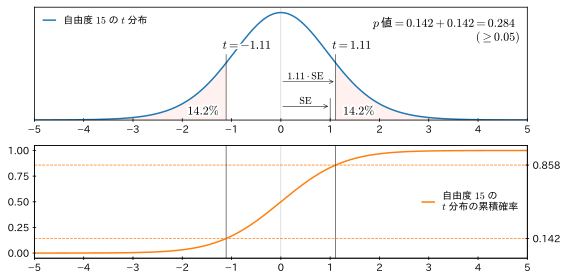

In [ ]:
#@title $p$ 値のイメージ { display-mode: "form" }
%reset -f
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

n = 16 # サンプルサイズ

# 標本平均 $\bar{x}$ の分布を描画
fig, axes = plt.subplots(nrows=2,ncols=1,figsize=(8,4),facecolor='white')

ax = axes[0]

x_min, x_max = -5, 5
x = np.linspace(x_min, x_max, 1201)
t_dist_pdf = st.t.pdf(x,df=n-1)

# 確率密度関数の描画
ax.plot(x, t_dist_pdf, color='tab:blue', lw=1.5, label=f'自由度 ${n-1}$ の $t$ 分布')

t=10/9
p_value = st.t.sf(abs(t), df=n-1)*2

for t0 in [t,-t]:
  ax.vlines(t0,ymin=0,ymax=0.24,lw=0.5,color='black')
  text = ax.text( t0-0.07, 0.26, f'$t={t0:.2f}$',fontsize=12,c='black')
  text.set_path_effects([pe.Stroke(linewidth=4,foreground='white'),pe.Normal()])

text = ax.text(t+0.15, 0.02, f'${p_value*50:.1f}\%$',fontsize=12,c='black')
text.set_path_effects([pe.Stroke(linewidth=4,foreground='white'),pe.Normal()])

text = ax.text(-t-0.15, 0.02, f'${p_value*50:.1f}\%$',fontsize=12,c='black',ha='right')
text.set_path_effects([pe.Stroke(linewidth=4,foreground='white'),pe.Normal()])

text = ax.text(4.75, 0.34, f'$p\,$値$={p_value/2:.3f}+{p_value/2:.3f}={p_value:.3f}$',fontsize=12,c='black',ha='right')
text = ax.text(4.85, 0.29, r'$( \geq 0.05)$',fontsize=12,c='black',ha='right')

# 塗りつぶし
for mask in ((x >= t),(x <= -t)):
  x_fill = x[mask]
  y_fill = t_dist_pdf[mask]
  ax.fill_between(x_fill, y_fill, color='mistyrose', alpha=0.5)

ah = 0.05
d = 0.03

ax.vlines(1,ymin=0,ymax=ah+d,lw=0.5,color='black')
ax.annotate('', xytext=(0,ah), xy=(1, ah),arrowprops=dict(arrowstyle='->',lw=0.5))
ax.text(0.5,ah+0.3*d,'$\mathrm{SE}$',ha='center')

ax.annotate('', xytext=(0,ah+3*d), xy=(t, ah+3*d),arrowprops=dict(arrowstyle='->',lw=0.5))
ax.text(0.5,ah+3.3*d,f'${{{t:.2f}}}\cdot\mathrm{{SE}}$',ha='center')


# 軸設定など
ax.set_ylim(0,)
ax.set_yticks([])
ax.legend(handlelength=1.2, frameon=False, loc='upper left')

ax = axes[1]
t_dist_cdf = st.t.cdf(x,df=n-1)

# 確率密度関数の描画
ax.plot(x, t_dist_cdf, color='tab:orange', lw=1.5, label=f'自由度 ${n-1}$ の\n$t$ 分布の累積確率')

for t0 in [t,-t]:
  ax.axvline(t0,lw=0.5,color='black')
  ax.axhline(st.t.cdf(t0, df=n-1),lw=0.75,c='tab:orange',ls='--')
ax.legend(handlelength=1.2, frameon=False, loc='center right')
ax.set_ylim(-0.05,1.05)

ax2 = ax.twinx()
ax2.set_ylim(-0.05,1.05)
ax2.set_yticks([st.t.cdf(-t, df=n-1),st.t.cdf(t, df=n-1)])
ax2.tick_params(axis='y', direction='inout')

for ax in axes:
  ax.set_xticks(np.arange(x_min,x_max+1,1))
  ax.set_xlim(x_min,x_max)
  ax.tick_params(axis='x', direction='inout')
  ax.tick_params(axis='y', direction='inout')
  ax.axvline(0, c='tab:gray', lw=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# p値の計算
%reset -f
import scipy.stats as st
n = 16
t_value = (140-130)/9
p_value = (1 - st.t.cdf(abs(t_value), df=n-1)) * 2
# 👆 補足
# (1) st.t.cdf(abs(t_value), df=n-1) で、t_value ときの上図のように累積確率 0.858 が得られる。
# (2) 1-st.t.cdf(abs(t_value), df=n-1) で、1-0.858 = 0.142 が得られる。
# (3) (1-st.t.cdf(abs(t_value), df=n-1))*2 で、0.284 が得られる。
print(f'両側検定における p 値は {p_value:.3f} です。')

両側検定における p 値は 0.284 です。



この $p$ 値を用いて、帰無仮説 $\mathrm{H}_0$ を「棄却できる」「棄却できない」を判断することもできます。例えば、有意水準 $5\%$ で $p$ 値が $28.4\%$ のとき、「帰無仮説 $\mathrm{H}_0$ は棄却できない」と判断します。また、次に示す例のように $p$ 値が $4.2\%$ のとき、「帰無仮説 $\mathrm{H}_0$ を棄却できる」と結論づけます。

- 帰無仮説 $\mathrm{H}_0$ の棄却は、$t$ 値でも、$p$ 値でも、どちらからでも判断できます。

## $\bar{x}=150$ のときの $t$ 値と $p$ 値

ところで、もし標本 $\mathrm{S}$ の標本平均 $\bar{x}$ が $150$ であれば、$t$ 値は次のようになります。すなわち $95\%$ 信頼区間（$\mu \pm 2.13 \cdot \mathrm{SE}$）の外側に位置します。

<br>

$$ t = \frac{150 - 130}{36/\sqrt{16}} = \frac{150 - 130}{9} = 2.22 $$

<br>

このときの $p$ 値は $0.042$（$4.2\%$）となります。つまり、仮説 $\mathrm{H}_0$ が正しいならば、$100$ 回中に約 $4$ 回程度しか得られないほど稀な標本であると考えられます。

よって、この $t=2.22$、$p=0.042$ という結果は仮説 $\mathrm{H}_0$ を統計的に棄却する根拠となります。

In [ ]:
# p値の計算
%reset -f
import scipy.stats as st
n = 16
t_value = (150-130)/9
p_value = (1 - st.t.cdf(abs(t_value), df=n-1)) * 2
# 👆 補足
# (1) st.t.cdf(abs(t_value), df=n-1) で、t_value ときの下図のように累積確率 0.979 が得られる。
# (2) 1-st.t.cdf(abs(t_value), df=n-1) で、0.021 が得られる。
# (3) (1-st.t.cdf(abs(t_value), df=n-1))*2 で、0.042 が得られる。
print(f'両側検定における p 値は {p_value:.3f} です。')

両側検定における p 値は 0.042 です。


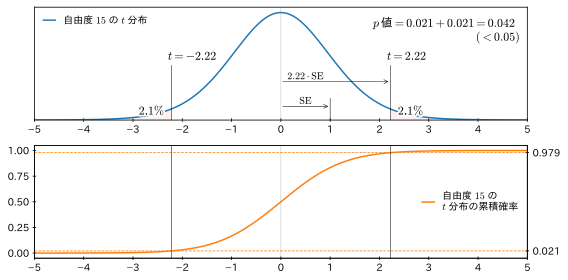

In [ ]:
#@title $p$ 値のイメージ { display-mode: "form" }
%reset -f
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.rcParams['mathtext.fontset'] = 'cm'

n = 16 # サンプルサイズ

# 標本平均 $\bar{x}$ の分布を描画
fig, axes = plt.subplots(nrows=2,ncols=1,figsize=(8,4),facecolor='white')

ax = axes[0]

x_min, x_max = -5, 5
x = np.linspace(x_min, x_max, 1201)
t_dist_pdf = st.t.pdf(x,df=n-1)

# 確率密度関数の描画
ax.plot(x, t_dist_pdf, color='tab:blue', lw=1.5, label=f'自由度 ${n-1}$ の $t$ 分布')

t=(150-130)/9
p_value = st.t.sf(abs(t), df=n-1)*2

for t0 in [t,-t]:
  ax.vlines(t0,ymin=0,ymax=0.20,lw=0.5,color='black')
  text = ax.text( t0-0.07, 0.22, f'$t={t0:.2f}$',fontsize=12,c='black')
  text.set_path_effects([pe.Stroke(linewidth=4,foreground='white'),pe.Normal()])

text = ax.text(t+0.15, 0.02, f'${p_value*50:.1f}\%$',fontsize=12,c='black')
text.set_path_effects([pe.Stroke(linewidth=4,foreground='white'),pe.Normal()])

text = ax.text(-t-0.15, 0.02, f'${p_value*50:.1f}\%$',fontsize=12,c='black',ha='right')
text.set_path_effects([pe.Stroke(linewidth=4,foreground='white'),pe.Normal()])

text = ax.text(4.75, 0.34, f'$p\,$値$={p_value/2:.3f}+{p_value/2:.3f}={p_value:.3f}$',fontsize=12,c='black',ha='right')
text = ax.text(4.85, 0.29, r'$( < 0.05)$',fontsize=12,c='black',ha='right')

# 塗りつぶし
for mask in ((x >= t),(x <= -t)):
  x_fill = x[mask]
  y_fill = t_dist_pdf[mask]
  ax.fill_between(x_fill, y_fill, color='mistyrose', alpha=0.5)

ah = 0.05
d = 0.03

ax.vlines(1,ymin=0,ymax=ah+d,lw=0.5,color='black')
ax.annotate('', xytext=(0,ah), xy=(1, ah),arrowprops=dict(arrowstyle='->',lw=0.5))
ax.text(0.5,ah+0.3*d,'$\mathrm{SE}$',ha='center')

ax.annotate('', xytext=(0,ah+3*d), xy=(t, ah+3*d),arrowprops=dict(arrowstyle='->',lw=0.5))
ax.text(0.5,ah+3.3*d,f'${{{t:.2f}}}\cdot\mathrm{{SE}}$',ha='center')


# 軸設定など
ax.set_ylim(0,)
ax.set_yticks([])
ax.legend(handlelength=1.2, frameon=False, loc='upper left')

ax = axes[1]
t_dist_cdf = st.t.cdf(x,df=n-1)

# 確率密度関数の描画
ax.plot(x, t_dist_cdf, color='tab:orange', lw=1.5, label=f'自由度 ${n-1}$ の\n$t$ 分布の累積確率')

for t0 in [t,-t]:
  ax.axvline(t0,lw=0.5,color='black')
  ax.axhline(st.t.cdf(t0, df=n-1),lw=0.75,c='tab:orange',ls='--')
ax.legend(handlelength=1.2, frameon=False, loc='center right')
ax.set_ylim(-0.05,1.05)

ax2 = ax.twinx()
ax2.set_ylim(-0.05,1.05)
ax2.set_yticks([st.t.cdf(-t, df=n-1),st.t.cdf(t, df=n-1)])
ax2.tick_params(axis='y', direction='inout')

for ax in axes:
  ax.set_xticks(np.arange(x_min,x_max+1,1))
  ax.set_xlim(x_min,x_max)
  ax.tick_params(axis='x', direction='inout')
  ax.tick_params(axis='y', direction='inout')
  ax.axvline(0, c='tab:gray', lw=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

なお、$p$ 値は「**有意確率**」とも呼ばれます。

- 「有意」とは、「偶然では説明できないほどの差があるかもしれない」という意味での「意味の有る（有意）」を指しています。
- 「有意確率」という言葉から<font color='deeppink'>「値が大きいほど有意である」と誤解されがちですが、実際には**「逆」**</font>なので注意してください。$p$ 値が小さいほど「仮説 $\mathrm{H}_0$ のもとではまず得られそうにない標本 $\mathrm{S}$ が観測されたこと」を意味します。
- $p$ 値は「有意である確率」ではなく、あくまで「有意かどうかを判断するための指標」になります。


### 定着確認

- 母平均の検定において、$t$ 値がとり得る範囲を答えよ。
  - 解答：<font color='white'></font>
- 母平均の検定において、$p$ 値がとり得る範囲を答えよ。
- 仮説 $\mathrm{H}_{0}$ のもとで極めて稀にしか観測されないような標本 $\mathrm{S}$ を考える。このとき、仮説 $\mathrm{H}_{0}$ と 標本 $\mathrm{S}$ から求められる $t$ 値の絶対値は、（相対的に）大きな値となるか、小さな値となるか。
- 仮説 $\mathrm{H}_{0}$ のもとで極めて稀にしか観測されないような標本 $\mathrm{S}$ を考える。このとき、仮説 $\mathrm{H}_{0}$ と 標本 $\mathrm{S}$ から求められる $p$ 値は、（相対的に）大きな値となるか、小さな値となるか。
- 仮説 $\mathrm{H}_{0}$ を棄却すべきと判断するのは、$t$ 値の絶対値が大きいときか、小さいときか。
- 仮説 $\mathrm{H}_{0}$ を棄却すべきと判断するのは、$p$ 値が大きいときか、小さいときか。
- 有意水準 $5\%$ で仮説検定を実施したところ、$p$ 値が $3\%$ となった。帰無仮説 $\mathrm{H}_{0}$ は棄却できるか、できないか答えよ。
- 有意水準 $5\%$ で仮説検定を実施したところ、$p$ 値が $3\%$ となった。対立仮説 $\mathrm{H}_{1}$ は採択（支持）できるか、できないか答えよ。



## **ここまでを整理**

ここまで確認してきた性質を踏まえ、一般に母平均の検定は次のような手順で実施されます。

1. 主張したい仮説を $\mathrm{H}_1$ とします。ただし、統計的に $\mathrm{H}_1$ を直接的に肯定することは困難なため、帰無仮説 $\mathrm{H}_0$ をあえて設定し、それを否定することで間接的に $\mathrm{H}_1$ を支持する根拠とします。
> 例：仮説 $\mathrm{H}_1$「新UIの適用によりコンテンツ閲覧数が増加する」を主張したい。そこで、帰無仮説 $\mathrm{H}_0$「新UIの適用によってコンテンツ閲覧数は変化しない」を設定する。
2. 帰無仮説 $\mathrm{H}_0$ が正しいと仮定した上で、標本 $\mathrm{S}$ から、$t$ 値と $p$ 値を算出します。
> 例：$t = 2.3$、$p = 0.03$ を得る。
3. 求めた $t$ 値と $p$ 値に基づき、帰無仮説 $\mathrm{H}_0$ のもとで標本 $\mathrm{S}$ のような結果が得られる確率（＝$p$ 値）を評価します。
> 例：帰無仮説 $\mathrm{H}_0$「新UIの適用によってコンテンツ閲覧数は変化しない」が正しい場合に、標本 $\mathrm{S}$ のような結果が観測される確率は計算上 $3\%$ 以下である。
4. この確率が十分に小さい場合、「たまたま稀なことが起きた」とは考えず、「帰無仮説 $\mathrm{H}_0$ が誤っている」と考えて $\mathrm{H}_0$ を棄却します。結果として $\mathrm{H}_1$ の主張に統計的な裏付けを与えることになります。
> 例：$3\%$ は十分に小さいとみなされるため、「偶然の結果」とは考えにくく、$\mathrm{H}_0$ は誤りであると判断する。したがって、$\mathrm{H}_1$「新UIの適用によりコンテンツ閲覧数が増加する」が統計的に支持される。


なお、ステップ「4.」において、$3\%$ という確率を「十分に小さい」とは見なさない判断も可能です。このような場合、$\mathrm{H}_0$ は棄却されず、$\mathrm{H}_1$ の主張はいったん保留されることになります。どの程度の確率を「小さい」と判断するかは、**有意水準**と呼ばれ、一般的には $5\%$ や $1\%$ といった基準が用いられます。



## **演習4**

教科書 p.110 【例題8.3】

> ある飲料メーカーから発売されているカフェインレスコーヒーには、カフェイン含有量が $3\%$ と表示されている。
>
> 無作為に $10$ 個の商品を抜き出して、カフェインの含有率を調査したところ、以下のようになった（単位 $\mathrm{[\%]}$）。
>
> 3.2　2.9　3.5　2.4　1.9　4.1　3.3　2.8　2.4　3.4
>
> このとき、カフェイン含有率の表示は正しくないと言えるか、標本は正規分布 $N(\mu,\, \sigma^2)$ に従うとして、有意水準 $5\%$ で検定せよ。


In [ ]:
# 演習4
%reset -f
import numpy as np
import scipy.stats as st

# ▼▼▼ 以下にコードを記述してください ▼▼▼

In [ ]:
#@title ⚠️演習4の解答例（まずは10分ほど独自に問題に取り組んだ後で参照してください） { display-mode: "form" }
%reset -f
import numpy as np
import scipy.stats as st

# 帰無仮説 H0： mu ＝ 3　含有率の表示は正しい
# 対立仮説 H1： mu ≠ 3　含有率の表示は正しくない
mu = 3

print(f'帰無仮説 H0 として「含有率は {3}% である（表示は正しい）」を設定する。')

# 母分散が未知なので「t検定」を用いる。
x = '3.2　2.9　3.5　2.4　1.9　4.1　3.3　2.8　2.4　3.4'
x = np.array( [ float(s) for s in x.split()],dtype=np.float64)

# サンプルサイズ n
n = len(x)

# 標準誤差
se = x.std(ddof=1)/n**0.5

# t値（t統計量）
t_value = (x.mean()-mu)/se

# t値に基づく棄却域 |t_value| > t_0025
t_0025 = st.t.ppf(0.975, df=n-1) # => 2.2621571628540993 ≒ 2.26

# p値（参考）
p_value = 2 * (1 - st.t.cdf(abs(t_value),df=n-1))

print(f't検定（自由度 {n-1}）において、有意水準 5% の（帰無仮説 H0）の棄却域は |t|>{t_0025:.2f} となる。')
print(f'これに対して標本から計算された z値は {t_value:.4f} であった。', end='')
print(f'また、p値 は {p_value:.4f}（{p_value:.1%}）であった。')

if abs(t_value) > t_0025:
  print(f'以上より、帰無仮説は棄却され、有意水準 5%で「含有率 {mu}% ではない（表示は正しくない）」といえる。')
else:
  print(f'以上より、帰無仮説は棄却できず、有意水準 5%で「含有率 {mu}% ではない（表示は正しくない）」とはいえない。')

帰無仮説 H0 として「含有率は 3% である（表示は正しい）」を設定する。
2.2621571628540993
t検定（自由度 9）において、有意水準 5% の（帰無仮説 H0）の棄却域は |t|>2.26 となる。
これに対して標本から計算された z値は -0.0491 であった。また、p値 は 0.9619（96.2%）であった。
以上より、帰無仮説は棄却できず、有意水準 5%で「含有率 3% ではない（表示は正しくない）」とはいえない。


## **母分散が既知のとき**

母分散 $\sigma^2$ が既知のときは、標準誤差 $\mathrm{SE}$ の推定式（$u/\sqrt{n}$）ではなく、論理式（$\sigma/\sqrt{n}$）を用いた <font color='deeppink'>$z$ 値という統計量</font> を計算し、それが標準正規分布に従うという性質を利用した $z$ 検定を行います。

$$ z = \frac{\bar{x} - \mu}{\mathrm{SE}} = \frac{\bar{x} - \mu}{\sigma/\sqrt{n}} $$



### **例題**

教科書 p.106 【例題8.1】

> ある自動車会社のハイブリッドカーの燃費は、公称では $35\mathrm{km/L}$ であるという。この車を無作為に $10$ 台選び走行実験をしたところ、$10$ 台の燃費の平均は $34.16\mathrm{km/L}$ であった。
>
> これまでの実験データから、燃費データが分散 $1.5^2$ の正規分布に従うことが分かっているとき、このハイブリッドカーの燃費の平均は $35\mathrm{km/L}$ でないといってよいか。有意水準 $5\%$ で検定せよ。


In [ ]:
# 解答例
%reset -f
import scipy.stats as st

# 帰無仮説 H0： mu ＝ 35
# 対立仮説 H1： mu ≠ 35
mu = 35

print(f'帰無仮説 H0 として「燃費平均は {mu}km/L である」を設定する。')

# 母分散 sigma^2 = 1.5^2 が既知なので z検定 を用いる。
sigma = 1.5

# サンプルサイズ n = 10、標本平均 x_bar = 34.1
n = 10
x_bar = 34.16

# 標準誤差
se = sigma/n**0.5

# z値（z統計量）
z_value = (x_bar-mu)/se

# z値に基づく棄却域 |z_value| > z_0025
z_0025 = st.norm.ppf(0.975, loc=0, scale=1) # => 1.959963984540054 ≒ 1.96

# p値（参考）
p_value = 2 * (1 - st.norm.cdf(abs(z_value)))

print(f'z検定において、有意水準 5% の（帰無仮説 H0）の棄却域は |z|>{z_0025:.2f} となる。')
print(f'これに対して標本から計算された z値は {z_value:.2f} であった。', end='')
print(f'また、p値 は {p_value:.4f}（{p_value:.1%}）であった。')

if abs(z_value) > z_0025:
  print(f'以上より、帰無仮説は棄却され、有意水準 5%で「{mu}km/L ではない」といえる。')
else:
  print(f'以上より、帰無仮説は棄却できず、有意水準 5%で「{mu}km/L ではない」とはいえない。')

帰無仮説 H0 として「燃費平均は 35km/L である」を設定する。
z検定において、有意水準 5% の（帰無仮説 H0）の棄却域は |z|>1.96 となる。
これに対して標本から計算された z値は -1.77 であった。また、p値 は 0.0766（7.7%）であった。
以上より、帰無仮説は棄却できず、有意水準 5%で「35km/L ではない」とはいえない。


## **演習5**

ある会社の工場では、自社製の機械を用いて $10\mathrm{cm}$ の円盤を製造している。この円盤を無作為に $9$ 個抽出して直径を測ったところ、その平均は $10.06\mathrm{cm}$ であった。このとき、この機械は正常に動作していなと言えるか。有意水準 $5\%$ で検定せよ。ただし、この円盤の直径は分散 $0.01$ の正規分布に従っているとしてよい。

In [ ]:
%reset -f
import scipy.stats as st

# ▼▼▼ 以下にコードを記述してください ▼▼▼

In [ ]:
#@title ⚠️演習5の解答例（独自に問題に取り組んだ後で参照してください） { display-mode: "form" }
%reset -f
import scipy.stats as st

# 帰無仮説 H0： mu ＝ 10　機械は正常に動いている
# 対立仮説 H1： mu ≠ 10　機械は正常に動いていない
mu = 10

print(f'帰無仮説 H0 として「円盤直径は {mu}cm である（機械は正常に動いている）」を設定する。')

# 母分散 sigma^2 = 0.01 が既知なので z検定 を用いる。
sigma = 0.01**0.5

# サンプルサイズ n = 9、標本平均 x_bar = 10.06
n = 9
x_bar = 10.06

# 標準誤差
se = sigma/n**0.5

# z値（z統計量）
z_value = (x_bar-mu)/se

# z値に基づく棄却域 |z_value| > z_0025
z_0025 = st.norm.ppf(0.975, loc=0, scale=1) # => 1.959963984540054 ≒ 1.96

# p値（参考）
p_value = 2 * (1 - st.norm.cdf(abs(z_value)))

print(f'z検定において、有意水準 5% の（帰無仮説 H0）の棄却域は |z|>{z_0025:.2f} となる。')
print(f'これに対して標本から計算された z値は {z_value:.2f} であった。', end='')
print(f'また、p値 は {p_value:.4f}（{p_value:.1%}）であった。')

if abs(z_value) > z_0025:
  print(f'以上より、帰無仮説は棄却され、有意水準 5%で「{mu}cm ではない（正常に動いていない）」といえる。')
else:
  print(f'以上より、帰無仮説は棄却できず、有意水準 5%で「{mu}cm ではない（正常に動いていない）」とはいえない。')

帰無仮説 H0 として「円盤直径は 10cm である（機械は正常に動いている）」を設定する。
z検定において、有意水準 5% の（帰無仮説 H0）の棄却域は |z|>1.96 となる。
これに対して標本から計算された z値は 1.80 であった。また、p値 は 0.0719（7.2%）であった。
以上より、帰無仮説は棄却できず、有意水準 5%で「10cm ではない（正常に動いていない）」とはいえない。


# 母平均の検定の使い分けについて

母平均の検定（＝母平均に**差があること**を主張するための検定）において、どの手法を用いるべきかを整理すると次のようになります。ただし、母集団がコーシー分布など極端な分布でないことを前提とします。

- 標本サイズ $n$ が十分に大きいとき（中心極限定理が適用可能な場合）  
  - 母分散 $\sigma$ が既知
    - 母集団の分布が正規分布 → $\sigma$ を使って $z$ 検定  
    - 母集団の分布が不明 → $\sigma$ を使って $z$ 検定（中心極限定理により）
  - 母分散 $\sigma$ が未知
    - 母集団の分布が正規分布 → 不偏標準偏差 $u$ を使って $t$ 検定
    - 母集団の分布が不明 → 不偏標準偏差 $u$ を使って $t$ 検定（または近似的に $z$ 検定も可）

- 標本サイズ $n$ が小さいとき（中心極限定理が使えない）
  - 母分散 $\sigma$ が既知
    - 母集団の分布が正規分布 → $\sigma$ を使って **$z$ 検定**
    - 母集団の分布が不明 → **検定は原則困難**（正規性の仮定が不可欠）
       - 代替としてノンパラメトリック検定（例：Wilcoxon符号付き順位検定など）の適用を検討。また「平均差」を議論すること自体が妥当かを再検討。
  - 母分散 $\sigma$ が未知
    - 母集団の分布が正規分布 → $u$ を使って **$t$ 検定**
    - 母集団の分布が不明 → **検定は原則困難**（正規性の仮定が不可欠）
       - 代替としてノンパラメトリック検定（例：Wilcoxon符号付き順位検定など）の適用を検討。また「平均差」を議論すること自体が妥当かを再検討。

なお「母平均に**差がないこと**（＝統計的に意味のある差が存在しないこと）」を主張したい場合は、通常の仮説検定では不十分で、**等価性検定（TOST法）** を用いる必要があります。